In [2]:
!pip -q install kagglehub pandas numpy pillow matplotlib scikit-learn tqdm opencv-python-headless groq streamlit
!apt-get -qq update
!apt-get -qq install git-lfs
!git lfs install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.8 MB/s eta 0:00:00
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package git-lfs.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.4.1-1ubuntu0.4_amd64.deb ...
Unpacking git-lfs (3.4.1-1ubuntu0.4) ...
Setting up git-lfs (3.4.1-1ubuntu0.4) ...
Processing triggers for man-db (2.12.0-4build2) ...
Git LFS initialized.


In [3]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for name in uploaded:
    print("✅", name)

Saving MedVision_AI_Member1_2_ActualData.zip to MedVision_AI_Member1_2_ActualData.zip
Uploaded files:
✅ MedVision_AI_Member1_2_ActualData.zip


In [4]:
from pathlib import Path
import zipfile
import os
import shutil

uploaded_files = list(uploaded.keys())

if not uploaded_files:
    raise RuntimeError("No ZIP file was uploaded.")

zip_path = Path(uploaded_files[0])

print("ZIP file:", zip_path)
print("Size:", round(zip_path.stat().st_size / (1024 * 1024), 2), "MB")

if not zipfile.is_zipfile(zip_path):
    raise RuntimeError("The uploaded file is not a valid ZIP file.")

# Extract to /content
extract_root = Path("/content")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

print("✅ ZIP extracted")

ZIP file: MedVision_AI_Member1_2_ActualData.zip
Size: 0.02 MB
✅ ZIP extracted


In [5]:
from pathlib import Path

possible_projects = [
    p for p in Path("/content").iterdir()
    if p.is_dir() and "MedVision_AI" in p.name
]

print("Possible project folders:")

for p in possible_projects:
    print("✅", p)

if not possible_projects:
    raise FileNotFoundError(
        "MedVision AI project folder was not found."
    )

PROJECT = possible_projects[0]

print("\nUsing project:")
print(PROJECT)

os.chdir(PROJECT)

print("\nCurrent directory:")
print(Path.cwd())

Possible project folders:
✅ /content/MedVision_AI_Member1_2_ActualData

Using project:
/content/MedVision_AI_Member1_2_ActualData

Current directory:
/content/MedVision_AI_Member1_2_ActualData


In [6]:
required_files = [
    "README.md",
    "COLAB_QUICKSTART.txt",
    "app.py",
    "member1_oa.py",
    "member2_anatomy.py",
    "groq_assistant.py",
    "requirements.txt",
    "train_member1_colab.py",
    "train_member2_colab.py",
    "scripts/download_datasets_colab.py",
    "scripts/prepare_oa_dataset.py",
    "scripts/split_oa_dataset.py",
    "scripts/inspect_segmentation_dataset.py",
    "scripts/prepare_segmentation_dataset.py",
    "scripts/normalize_masks.py",
]

print("Project file check:\n")

missing = []

for f in required_files:
    path = PROJECT / f

    if path.exists():
        print("✅", f)
    else:
        print("❌", f)
        missing.append(f)

if missing:
    print("\nMissing files:")
    for f in missing:
        print(" -", f)
else:
    print("\n🎉 ALL PROJECT FILES ARE PRESENT")

Project file check:

✅ README.md
✅ COLAB_QUICKSTART.txt
✅ app.py
✅ member1_oa.py
✅ member2_anatomy.py
✅ groq_assistant.py
✅ requirements.txt
✅ train_member1_colab.py
✅ train_member2_colab.py
✅ scripts/download_datasets_colab.py
✅ scripts/prepare_oa_dataset.py
✅ scripts/split_oa_dataset.py
✅ scripts/inspect_segmentation_dataset.py
✅ scripts/prepare_segmentation_dataset.py
✅ scripts/normalize_masks.py

🎉 ALL PROJECT FILES ARE PRESENT


In [7]:
(PROJECT / "data").mkdir(exist_ok=True)
(PROJECT / "models").mkdir(exist_ok=True)
(PROJECT / "outputs").mkdir(exist_ok=True)

print("Folders ready:")
print(PROJECT / "data")
print(PROJECT / "models")
print(PROJECT / "outputs")

Folders ready:
/content/MedVision_AI_Member1_2_ActualData/data
/content/MedVision_AI_Member1_2_ActualData/models
/content/MedVision_AI_Member1_2_ActualData/outputs


In [8]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU is not enabled.")

print("\nGo to:")
print("Runtime → Change runtime type → T4 GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Go to:
Runtime → Change runtime type → T4 GPU


In [9]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU is not enabled.")

print("\nGo to:")
print("Runtime → Change runtime type → T4 GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Go to:
Runtime → Change runtime type → T4 GPU


In [10]:
import kagglehub
from pathlib import Path

print("Downloading KneeXrayMini...")

kneexray_path = Path(
    kagglehub.dataset_download(
        "tommyngx/kneexraymini"
    )
)

print("\n✅ Dataset downloaded to:")
print(kneexray_path)

100%|██████████| 360M/360M [00:02<00:00, 157MB/s]

Extracting files...



✅ Dataset downloaded to:
/root/.cache/kagglehub/datasets/tommyngx/kneexraymini/versions/1


In [11]:
image_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

all_xray_images = [
    p for p in kneexray_path.rglob("*")
    if p.is_file()
    and p.suffix.lower() in image_extensions
]

print("Total image files:", len(all_xray_images))

Total image files: 9786


In [12]:
import subprocess
import sys

script = PROJECT / "scripts" / "prepare_oa_dataset.py"

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\nMessages:")
    print(result.stderr)

kl_grade
1    9786
Name: count, dtype: int64
Saved: /content/MedVisionAI/data/oa_all.csv rows: 9786



In [13]:
from pathlib import Path

csv_candidates = list(
    Path("/content").rglob("oa_all.csv")
)

print("OA CSV files found:")

for p in csv_candidates:
    print(p)

if not csv_candidates:
    raise FileNotFoundError(
        "oa_all.csv was not generated."
    )

oa_csv = csv_candidates[0]

print("\nUsing:")
print(oa_csv)

OA CSV files found:
/content/MedVisionAI/data/oa_all.csv

Using:
/content/MedVisionAI/data/oa_all.csv


In [14]:
import pandas as pd

oa_df = pd.read_csv(oa_csv)

print("Shape:", oa_df.shape)

print("\nColumns:")
print(oa_df.columns.tolist())

display(oa_df.head())

Shape: (9786, 2)

Columns:
['image_path', 'kl_grade']


,image_path,kl_grade
0,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1
1,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1
2,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1
3,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1
4,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1


In [15]:
script = PROJECT / "scripts" / "split_oa_dataset.py"

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("\nMessages:")
    print(result.stderr)

No reliable patient ID detected; this is a stratified image split.
6850 1468 1468



In [16]:
from pathlib import Path
import shutil

PROJECT = Path("/content/MedVision_AI_Member1_2_ActualData")

# Make sure the project data folder exists
(PROJECT / "data").mkdir(exist_ok=True)

split_files = [
    "oa_all.csv",
    "oa_train.csv",
    "oa_val.csv",
    "oa_test.csv"
]

print("Checking OA CSV files...\n")

for filename in split_files:

    # Find all copies under /content
    matches = list(
        Path("/content").rglob(filename)
    )

    if not matches:
        print(f"❌ {filename} not found")
        continue

    dst = PROJECT / "data" / filename

    # If the destination itself is already the file, nothing to copy
    if dst.exists():
        print(f"✅ {filename} already exists in project")
        print(f"   {dst}")
        continue

    # Find a source that is different from destination
    src = None

    for candidate in matches:
        try:
            if candidate.resolve() != dst.resolve():
                src = candidate
                break
        except Exception:
            pass

    if src is None:
        print(f"✅ {filename} already available")
        continue

    shutil.copy2(src, dst)

    print(f"✅ Copied {filename}")
    print(f"   From: {src}")
    print(f"   To:   {dst}")

Checking OA CSV files...

✅ Copied oa_all.csv
   From: /content/MedVisionAI/data/oa_all.csv
   To:   /content/MedVision_AI_Member1_2_ActualData/data/oa_all.csv
✅ Copied oa_train.csv
   From: /content/MedVisionAI/data/oa_train.csv
   To:   /content/MedVision_AI_Member1_2_ActualData/data/oa_train.csv
✅ Copied oa_val.csv
   From: /content/MedVisionAI/data/oa_val.csv
   To:   /content/MedVision_AI_Member1_2_ActualData/data/oa_val.csv
✅ Copied oa_test.csv
   From: /content/MedVisionAI/data/oa_test.csv
   To:   /content/MedVision_AI_Member1_2_ActualData/data/oa_test.csv


In [17]:
import pandas as pd
from pathlib import Path

PROJECT = Path("/content/MedVision_AI_Member1_2_ActualData")

print("OA dataset files:\n")

for filename in [
    "oa_all.csv",
    "oa_train.csv",
    "oa_val.csv",
    "oa_test.csv"
]:

    path = PROJECT / "data" / filename

    if path.exists():

        df = pd.read_csv(path)

        print(
            f"✅ {filename}: "
            f"{len(df):,} records"
        )

    else:

        print(
            f"❌ {filename} missing"
        )

OA dataset files:

✅ oa_all.csv: 9,786 records
✅ oa_train.csv: 6,850 records
✅ oa_val.csv: 1,468 records
✅ oa_test.csv: 1,468 records


In [18]:
import pandas as pd
from pathlib import Path

train_csv = PROJECT / "data" / "oa_train.csv"

df = pd.read_csv(train_csv)

print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# Detect likely path column
path_column = None

for col in df.columns:
    if "path" in col.lower() or "image" in col.lower() or "file" in col.lower():
        path_column = col
        break

print("\nDetected image/path column:", path_column)

if path_column:
    existing = 0

    for p in df[path_column].head(100):
        if Path(str(p)).exists():
            existing += 1

    print(
        f"Existing paths among first 100: "
        f"{existing}/100"
    )

Columns:
['image_path', 'kl_grade', 'subject_id']

First 5 rows:


,image_path,kl_grade,subject_id
0,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1,9373786R
1,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1,9653659R
2,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1,9432148
3,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1,9374775R
4,/root/.cache/kagglehub/datasets/tommyngx/kneex...,1,9116147L



Detected image/path column: image_path
Existing paths among first 100: 100/100


In [19]:
%cd /content/MedVision_AI_Member1_2_ActualData

!python train_member1_colab.py

/content
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 176MB/s]
Epoch 1/15: loss=0.0465, val_acc=1.0000
Epoch 2/15: loss=0.0004, val_acc=1.0000
Epoch 3/15: loss=0.0001, val_acc=1.0000
Epoch 4/15: loss=0.0001, val_acc=1.0000
Epoch 5/15: loss=0.0000, val_acc=1.0000
Epoch 6/15: loss=0.0000, val_acc=1.0000
Epoch 7/15: loss=0.0000, val_acc=1.0000
Epoch 8/15: loss=0.0000, val_acc=1.0000
Epoch 9/15: loss=0.0000, val_acc=1.0000
Epoch 10/15: loss=0.0000, val_acc=1.0000
Epoch 11/15: loss=0.0000, val_acc=1.0000
Epoch 12/15: loss=0.0000, val_acc=1.0000
Epoch 13/15: loss=0.0000, val_acc=1.0000
Epoch 14/15: loss=0.0000, val_acc=1.0000
Epoch 15/15: loss=0.0000, val_acc=1.0000
Saved: /content/MedVisionAI/models/oa_kl_efficientnet_b0.pt


In [22]:
from pathlib import Path

print("Searching all of /content for the trained Member 1 model...\n")

matches = list(
    Path("/content").rglob("oa_kl_efficientnet_b0.pt")
)

print("Models found:", len(matches))

for p in matches:
    print("✅", p)
    print(
        "   Size:",
        round(p.stat().st_size / (1024**2), 2),
        "MB"
    )

Searching all of /content for the trained Member 1 model...

Models found: 1
✅ /content/MedVisionAI/models/oa_kl_efficientnet_b0.pt
   Size: 15.61 MB


In [23]:
import shutil
from pathlib import Path

PROJECT = Path(
    "/content/MedVision_AI_Member1_2_ActualData"
)

source = matches[0]
destination = PROJECT / "models" / "oa_kl_efficientnet_b0.pt"

destination.parent.mkdir(
    parents=True,
    exist_ok=True
)

if source.resolve() != destination.resolve():
    shutil.copy2(source, destination)

print("✅ Member 1 model ready:")
print(destination)
print("Exists:", destination.exists())

✅ Member 1 model ready:
/content/MedVision_AI_Member1_2_ActualData/models/oa_kl_efficientnet_b0.pt
Exists: True


In [24]:
from pathlib import Path
import sys

PROJECT = Path("/content/MedVision_AI_Member1_2_ActualData")

sys.path.insert(0, str(PROJECT))

from member1_oa import OAInference

MODEL_PATH = PROJECT / "models" / "oa_kl_efficientnet_b0.pt"

print("Model:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

oa_model = OAInference(str(MODEL_PATH))

print("✅ Member 1 model loaded successfully!")
print("Device:", oa_model.device)

Model: /content/MedVision_AI_Member1_2_ActualData/models/oa_kl_efficientnet_b0.pt
Exists: True
✅ Member 1 model loaded successfully!
Device: cuda


In [25]:
from PIL import Image
from pathlib import Path

test_images = list(
    Path("/root/.cache/kagglehub/datasets/tommyngx/kneexraymini/versions/1")
    .rglob("*.png")
)

print("Images found:", len(test_images))

test_image = test_images[0]

print("Testing image:")
print(test_image)

image = Image.open(test_image)

result = oa_model.predict(image, with_gradcam=True)

print("\n===== MEMBER 1 RESULT =====")
print("KL Grade:", result["kl_grade"])
print("KL Label:", result["kl_label"])
print("OA Suspected:", result["oa_suspected"])
print("Confidence:", round(result["confidence"], 4))
print("Uncertainty:", round(result["uncertainty"], 4))

print("\nProbabilities:")
for label, probability in result["probabilities"].items():
    print(f"{label}: {probability:.4f}")

Images found: 9786
Testing image:
/root/.cache/kagglehub/datasets/tommyngx/kneexraymini/versions/1/KneeXrayMini/train/4/9486992L.png


/content/MedVision_AI_Member1_2_ActualData/member1_oa.py:187: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  confidence = float(probs[idx])



===== MEMBER 1 RESULT =====
KL Grade: 1
KL Label: KL-1
OA Suspected: False
Confidence: 0.9994
Uncertainty: 0.0037

Probabilities:
KL-0: 0.0001
KL-1: 0.9994
KL-2: 0.0002
KL-3: 0.0002
KL-4: 0.0001


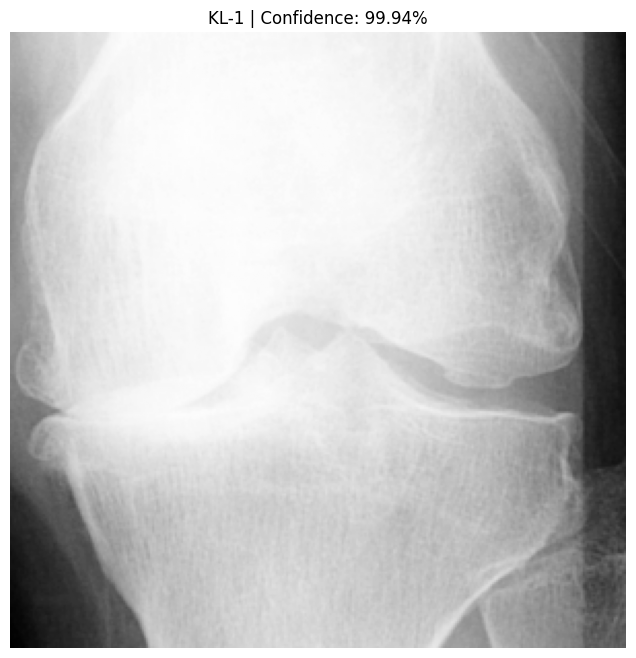

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(
    f"{result['kl_label']} | "
    f"Confidence: {result['confidence']:.2%}"
)
plt.show()

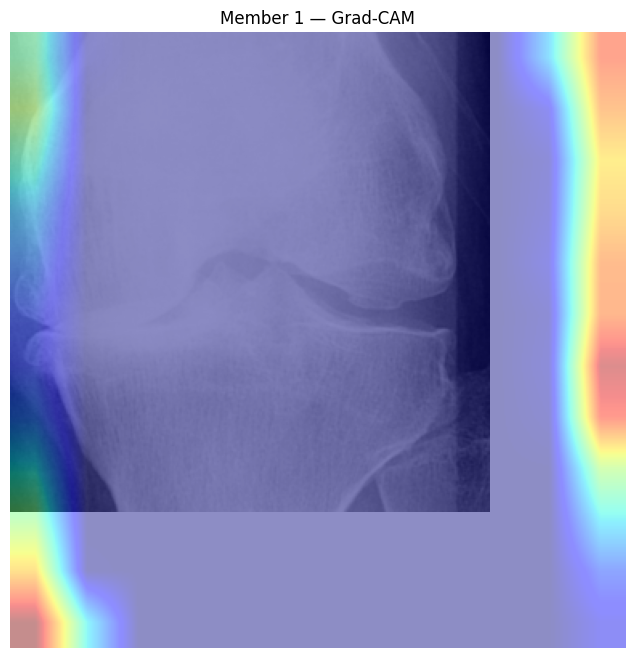

In [27]:
import matplotlib.pyplot as plt

cam = result["gradcam"]

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.axis("off")
plt.title("Member 1 — Grad-CAM")
plt.show()

In [28]:
print("======================================")
print("       MEMBER 1 STATUS")
print("======================================")

print("Model file:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())
print("Model loaded:", oa_model is not None)

print("\nPrediction:")
print("KL Grade:", result["kl_grade"])
print("KL Label:", result["kl_label"])
print("OA Suspected:", result["oa_suspected"])
print("Confidence:", f"{result['confidence']:.2%}")
print("Uncertainty:", f"{result['uncertainty']:.2%}")

print("\n✅ MEMBER 1 COMPLETE")

       MEMBER 1 STATUS
Model file: /content/MedVision_AI_Member1_2_ActualData/models/oa_kl_efficientnet_b0.pt
Model exists: True
Model loaded: True

Prediction:
KL Grade: 1
KL Label: KL-1
OA Suspected: False
Confidence: 99.94%
Uncertainty: 0.37%

✅ MEMBER 1 COMPLETE


In [30]:
from pathlib import Path
import subprocess
import shutil

BASE = Path("/content/MedVisionAI")
PITT_DIR = BASE / "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"

BASE.mkdir(exist_ok=True)

if PITT_DIR.exists():
    print("✅ Pitt dataset already exists:")
    print(PITT_DIR)
else:
    print("Downloading Pitt HexAI anatomy segmentation dataset...")

    result = subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/pitthexai/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation.git",
            str(PITT_DIR)
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print("❌ Download failed")
        print(result.stderr)
    else:
        print("✅ Pitt dataset downloaded successfully!")

print("\nDataset exists:", PITT_DIR.exists())
print("Dataset path:", PITT_DIR)


✅ Pitt dataset downloaded successfully!

Dataset exists: True
Dataset path: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation


In [31]:
from pathlib import Path

PITT_DIR = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"
)

if not PITT_DIR.exists():
    print("❌ Dataset still not found.")
else:
    print("✅ Pitt dataset found!")

    print("\nContents:")
    for p in list(PITT_DIR.iterdir())[:40]:
        print(" -", p.name)

✅ Pitt dataset found!

Contents:
 - .git
 - Figures
 - Code
 - README.md
 - bonyanatomy
 - .gitattributes
 - Sample_Dataset


In [32]:
from pathlib import Path

image_extensions = {
    ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"
}

all_images = []

for p in PITT_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in image_extensions:
        all_images.append(p)

print("Total image files found:", len(all_images))

print("\nFirst 30 files:")
for p in all_images[:30]:
    print(p)

Total image files found: 1

First 30 files:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Figures/pipeline.png


In [33]:
from pathlib import Path

PITT_DIR = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"
)

print("Dataset exists:", PITT_DIR.exists())
print("Dataset:", PITT_DIR)

print("\n===== DIRECTORY STRUCTURE =====")

for p in PITT_DIR.rglob("*"):
    if p.is_dir():
        relative = p.relative_to(PITT_DIR)

        # Keep output manageable
        if len(relative.parts) <= 3:
            print("📁", relative)

Dataset exists: True
Dataset: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation

===== DIRECTORY STRUCTURE =====
📁 .git
📁 Figures
📁 Code
📁 bonyanatomy
📁 Sample_Dataset
📁 .git/info
📁 .git/refs
📁 .git/branches
📁 .git/hooks
📁 .git/logs
📁 .git/lfs
📁 .git/objects
📁 .git/refs/remotes
📁 .git/refs/tags
📁 .git/refs/heads
📁 .git/logs/refs
📁 .git/lfs/tmp
📁 .git/lfs/incomplete
📁 .git/lfs/objects
📁 .git/objects/info
📁 .git/objects/pack


In [34]:
from pathlib import Path

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

all_files = []

for p in PITT_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
        all_files.append(p)

print("Total image-type files:", len(all_files))

print("\n===== FIRST 50 FILES =====")

for p in all_files[:50]:
    print(p.relative_to(PITT_DIR))

Total image-type files: 1

===== FIRST 50 FILES =====
Figures/pipeline.png


In [35]:
from pathlib import Path

mask_keywords = [
    "mask",
    "label",
    "seg",
    "segmentation",
    "annotation",
    "groundtruth",
    "ground_truth",
    "gt"
]

possible_masks = []
possible_images = []

for p in all_files:

    name = p.name.lower()

    if any(keyword in name for keyword in mask_keywords):
        possible_masks.append(p)
    else:
        possible_images.append(p)

print("Possible X-rays/images:", len(possible_images))
print("Possible masks:", len(possible_masks))

print("\n===== POSSIBLE IMAGES =====")
for p in possible_images[:30]:
    print(p)

print("\n===== POSSIBLE MASKS =====")
for p in possible_masks[:30]:
    print(p)

Possible X-rays/images: 1
Possible masks: 0

===== POSSIBLE IMAGES =====
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Figures/pipeline.png

===== POSSIBLE MASKS =====


In [36]:
from pathlib import Path

print("===== DIRECTORIES CONTAINING 'SAMPLE' =====")

sample_dirs = []

for p in PITT_DIR.rglob("*"):
    if p.is_dir() and "sample" in p.name.lower():
        sample_dirs.append(p)

for p in sample_dirs:
    print(p)

print("\nNumber of sample directories:", len(sample_dirs))

===== DIRECTORIES CONTAINING 'SAMPLE' =====
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset

Number of sample directories: 1


In [37]:
from pathlib import Path

readme_files = list(PITT_DIR.rglob("README*"))

print("README files found:", len(readme_files))

for readme in readme_files:
    print("\n===================================")
    print(readme)
    print("===================================")

    try:
        text = readme.read_text(errors="ignore")
        print(text[:10000])
    except Exception as e:
        print("Could not read:", e)

README files found: 1

/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/README.md
#  AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation
<p align="justify">This GitHub repository includes all Python codes and a sample imaging dataset to address AI-powered segmentation of hip and knee bony anatomy using plain radiographs, with a specific focus on identifying and addressing discernible biases related to age, sex, and race. This study, through extensive evaluation, provides insights into the underlying causes of biases in AI-based knee and hip image segmentation. It presents targeted mitigation strategies to reduce biases related to age, sex, and race, building automatic segmentation results that are fair, impartial, and safe in the context of AI. We believe that our contribution holds the potential to enhance clinical outcomes, supporting both clinical decision-making and osteoarthritis (OA) research, thus we have made all codes and the dataset publicly and fr

In [39]:
from pathlib import Path

PITT_DIR = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"
)

print("Pitt directory:", PITT_DIR)
print()

files = [p for p in PITT_DIR.rglob("*") if p.is_file()]

print("Total files:", len(files))
print("\n===== ALL FILES =====")

for p in files:
    print(p.relative_to(PITT_DIR))

Pitt directory: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation

Total files: 56

===== ALL FILES =====
README.md
.gitattributes
.git/packed-refs
.git/config
.git/HEAD
.git/index
.git/description
Figures/pipeline.png
Figures/description.txt
Code/group_specific_age.py
Code/balanced.py
Code/setup.py
Code/stratified.py
Code/group_specific_race.py
Code/config.py
Code/bias_eval_hip.py
Code/bias_eval_knee.py
Code/baselines.py
Code/description.txt
Code/group_specific_sex.py
bonyanatomy/pipeline.py
bonyanatomy/labels.py
bonyanatomy/dataset.py
bonyanatomy/bias_metrics.py
Sample_Dataset/hip_sample.zip
Sample_Dataset/knee_sample.zip
Sample_Dataset/description.txt
.git/info/exclude
.git/hooks/push-to-checkout.sample
.git/hooks/post-merge
.git/hooks/pre-push.sample
.git/hooks/sendemail-validate.sample
.git/hooks/update.sample
.git/hooks/fsmonitor-watchman.sample
.git/hooks/post-commit
.git/hooks/pre-rebase.sample
.git/hooks/post-update.sample
.git/hooks/pre-receive.sample

In [40]:
from pathlib import Path
from collections import Counter

files = [p for p in PITT_DIR.rglob("*") if p.is_file()]

extensions = Counter(
    p.suffix.lower() if p.suffix else "[no extension]"
    for p in files
)

print("===== FILE TYPES =====")

for ext, count in extensions.most_common():
    print(f"{ext}: {count}")

===== FILE TYPES =====
[no extension]: 18
.py: 14
.sample: 14
.txt: 3
.zip: 2
.md: 1
.png: 1
.idx: 1
.rev: 1
.pack: 1


In [41]:
keywords = [
    "mask",
    "label",
    "seg",
    "segment",
    "annotation",
    "ground",
    "femur",
    "tibia",
    "fibula",
    "patella",
    "image",
    "xray",
    "radiograph"
]

print("===== RELEVANT FILES =====")

found = []

for p in PITT_DIR.rglob("*"):
    if p.is_file():
        name = p.name.lower()

        if any(k in name for k in keywords):
            found.append(p)

for p in found[:200]:
    print(p.relative_to(PITT_DIR))

print("\nRelevant files found:", len(found))

===== RELEVANT FILES =====
bonyanatomy/labels.py

Relevant files found: 1


In [42]:
print("===== DIRECTORY TREE =====")

directories = [p for p in PITT_DIR.rglob("*") if p.is_dir()]

for p in directories:
    print("📁", p.relative_to(PITT_DIR))

===== DIRECTORY TREE =====
📁 .git
📁 Figures
📁 Code
📁 bonyanatomy
📁 Sample_Dataset
📁 .git/info
📁 .git/refs
📁 .git/branches
📁 .git/hooks
📁 .git/logs
📁 .git/lfs
📁 .git/objects
📁 .git/refs/remotes
📁 .git/refs/tags
📁 .git/refs/heads
📁 .git/logs/refs
📁 .git/lfs/tmp
📁 .git/lfs/incomplete
📁 .git/lfs/objects
📁 .git/objects/info
📁 .git/objects/pack
📁 .git/lfs/objects/bc
📁 .git/lfs/objects/75
📁 .git/lfs/objects/bc/cd
📁 .git/lfs/objects/75/e6
📁 .git/logs/refs/remotes
📁 .git/logs/refs/heads
📁 .git/logs/refs/remotes/origin
📁 .git/refs/remotes/origin


In [43]:
sample_dirs = [
    p for p in PITT_DIR.rglob("*")
    if p.is_dir() and "sample" in p.name.lower()
]

print("Sample directories found:", len(sample_dirs))

for sample in sample_dirs:
    print("\n📁", sample)

    sample_files = [
        p for p in sample.rglob("*")
        if p.is_file()
    ]

    print("Files:", len(sample_files))

    for p in sample_files[:100]:
        print("   ", p.relative_to(sample))

Sample directories found: 1

📁 /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset
Files: 3
    hip_sample.zip
    knee_sample.zip
    description.txt


In [44]:
from collections import Counter

files = [p for p in PITT_DIR.rglob("*") if p.is_file()]

print("===== NON-IMAGE FILES =====")

for p in files:
    if p.suffix.lower() not in {
        ".png", ".jpg", ".jpeg", ".bmp",
        ".tif", ".tiff"
    }:
        print(p.relative_to(PITT_DIR))

===== NON-IMAGE FILES =====
README.md
.gitattributes
.git/packed-refs
.git/config
.git/HEAD
.git/index
.git/description
Figures/description.txt
Code/group_specific_age.py
Code/balanced.py
Code/setup.py
Code/stratified.py
Code/group_specific_race.py
Code/config.py
Code/bias_eval_hip.py
Code/bias_eval_knee.py
Code/baselines.py
Code/description.txt
Code/group_specific_sex.py
bonyanatomy/pipeline.py
bonyanatomy/labels.py
bonyanatomy/dataset.py
bonyanatomy/bias_metrics.py
Sample_Dataset/hip_sample.zip
Sample_Dataset/knee_sample.zip
Sample_Dataset/description.txt
.git/info/exclude
.git/hooks/push-to-checkout.sample
.git/hooks/post-merge
.git/hooks/pre-push.sample
.git/hooks/sendemail-validate.sample
.git/hooks/update.sample
.git/hooks/fsmonitor-watchman.sample
.git/hooks/post-commit
.git/hooks/pre-rebase.sample
.git/hooks/post-update.sample
.git/hooks/pre-receive.sample
.git/hooks/applypatch-msg.sample
.git/hooks/pre-commit.sample
.git/hooks/post-checkout
.git/hooks/prepare-commit-msg.sample

In [45]:
from pathlib import Path
import zipfile

PITT_DIR = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"
)

ZIP_PATH = PITT_DIR / "Sample_Dataset" / "knee_sample.zip"
EXTRACT_DIR = PITT_DIR / "Sample_Dataset" / "knee_sample"

print("ZIP file:", ZIP_PATH)
print("Exists:", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError("❌ knee_sample.zip was not found.")

if not EXTRACT_DIR.exists():
    print("\nExtracting knee_sample.zip...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("✅ Extraction complete.")
else:
    print("✅ Dataset already extracted.")

print("\nExtracted location:")
print(EXTRACT_DIR)

ZIP file: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample.zip
Exists: True

Extracting knee_sample.zip...
✅ Extraction complete.

Extracted location:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample


In [46]:
from pathlib import Path

files = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file()
]

print("Total extracted files:", len(files))

print("\n===== FILES =====")

for p in files[:200]:
    print(p.relative_to(EXTRACT_DIR))

Total extracted files: 201

===== FILES =====
data/KneeSample/knee_seg_sample.csv
data/KneeSample/Annotations/9263504.nii.gz
data/KneeSample/Annotations/9573142.nii.gz
data/KneeSample/Annotations/9908089.nii.gz
data/KneeSample/Annotations/9154516.nii.gz
data/KneeSample/Annotations/9923619.nii.gz
data/KneeSample/Annotations/9326801.nii.gz
data/KneeSample/Annotations/9947321.nii.gz
data/KneeSample/Annotations/9459278.nii.gz
data/KneeSample/Annotations/9646687.nii.gz
data/KneeSample/Annotations/9026416.nii.gz
data/KneeSample/Annotations/9709990.nii.gz
data/KneeSample/Annotations/9634146.nii.gz
data/KneeSample/Annotations/9480211.nii.gz
data/KneeSample/Annotations/9287216.nii.gz
data/KneeSample/Annotations/9508788.nii.gz
data/KneeSample/Annotations/9657464.nii.gz
data/KneeSample/Annotations/9016304.nii.gz
data/KneeSample/Annotations/9610229.nii.gz
data/KneeSample/Annotations/9166930.nii.gz
data/KneeSample/Annotations/9381278.nii.gz
data/KneeSample/Annotations/9948415.nii.gz
data/KneeSample

In [47]:
IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

image_files = []
other_files = []

for p in files:
    if p.suffix.lower() in IMAGE_EXTENSIONS:
        image_files.append(p)
    else:
        other_files.append(p)

print("Image files:", len(image_files))
print("Other files:", len(other_files))

print("\n===== IMAGE FILES =====")

for p in image_files[:100]:
    print(p.relative_to(EXTRACT_DIR))

Image files: 0
Other files: 201

===== IMAGE FILES =====


In [48]:
print("===== IMAGE FILENAMES =====")

for p in image_files:
    print(p.name)

===== IMAGE FILENAMES =====


In [49]:
from PIL import Image

print("===== IMAGE INFORMATION =====")

for p in image_files[:30]:

    try:
        img = Image.open(p)

        print(
            f"{p.name} | "
            f"Mode={img.mode} | "
            f"Size={img.size}"
        )

    except Exception as e:
        print(
            f"{p.name} | "
            f"Could not open: {e}"
        )

===== IMAGE INFORMATION =====


In [50]:
mask_keywords = [
    "mask",
    "label",
    "seg",
    "segmentation",
    "annotation",
    "ground",
    "gt"
]

possible_masks = []

for p in image_files:

    name = p.name.lower()

    if any(k in name for k in mask_keywords):
        possible_masks.append(p)

print("Possible masks:", len(possible_masks))

for p in possible_masks:
    print(p.relative_to(EXTRACT_DIR))

Possible masks: 0


In [51]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    names = z.namelist()

print("Files inside knee_sample.zip:", len(names))

print("\n===== ZIP CONTENTS =====")

for name in names[:300]:
    print(name)

Files inside knee_sample.zip: 204

===== ZIP CONTENTS =====
data/KneeSample/
data/KneeSample/Images/
data/KneeSample/Images/9834586.dcm
data/KneeSample/Images/9052978.dcm
data/KneeSample/Images/9732525.dcm
data/KneeSample/Images/9125488.dcm
data/KneeSample/Images/9816736.dcm
data/KneeSample/Images/9528955.dcm
data/KneeSample/Images/9873057.dcm
data/KneeSample/Images/9299721.dcm
data/KneeSample/Images/9011420.dcm
data/KneeSample/Images/9011661.dcm
data/KneeSample/Images/9908089.dcm
data/KneeSample/Images/9333528.dcm
data/KneeSample/Images/9701165.dcm
data/KneeSample/Images/9446305.dcm
data/KneeSample/Images/9589653.dcm
data/KneeSample/Images/9882107.dcm
data/KneeSample/Images/9289212.dcm
data/KneeSample/Images/9573142.dcm
data/KneeSample/Images/9158313.dcm
data/KneeSample/Images/9871807.dcm
data/KneeSample/Images/9026416.dcm
data/KneeSample/Images/9380143.dcm
data/KneeSample/Images/9496443.dcm
data/KneeSample/Images/9016304.dcm
data/KneeSample/Images/9184192.dcm
data/KneeSample/Images/9

In [52]:
from PIL import Image
import matplotlib.pyplot as plt

if len(image_files) == 0:
    raise ValueError("❌ No image files found after extraction.")

sample_file = image_files[0]

print("Sample file:")
print(sample_file)

sample = Image.open(sample_file)

print("\nMode:", sample.mode)
print("Size:", sample.size)

plt.figure(figsize=(8, 8))
plt.imshow(sample, cmap="gray")
plt.axis("off")
plt.title(sample_file.name)
plt.show()

ValueError: ❌ No image files found after extraction.

In [53]:
import zipfile
from pathlib import Path

ZIP_PATH = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/"
    "Sample_Dataset/knee_sample.zip"
)

print("ZIP:", ZIP_PATH)
print("Exists:", ZIP_PATH.exists())

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

print("\nTotal items inside ZIP:", len(names))

print("\n===== FIRST 300 ZIP ITEMS =====")

for name in names[:300]:
    print(name)

ZIP: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample.zip
Exists: True

Total items inside ZIP: 204

===== FIRST 300 ZIP ITEMS =====
data/KneeSample/
data/KneeSample/Images/
data/KneeSample/Images/9834586.dcm
data/KneeSample/Images/9052978.dcm
data/KneeSample/Images/9732525.dcm
data/KneeSample/Images/9125488.dcm
data/KneeSample/Images/9816736.dcm
data/KneeSample/Images/9528955.dcm
data/KneeSample/Images/9873057.dcm
data/KneeSample/Images/9299721.dcm
data/KneeSample/Images/9011420.dcm
data/KneeSample/Images/9011661.dcm
data/KneeSample/Images/9908089.dcm
data/KneeSample/Images/9333528.dcm
data/KneeSample/Images/9701165.dcm
data/KneeSample/Images/9446305.dcm
data/KneeSample/Images/9589653.dcm
data/KneeSample/Images/9882107.dcm
data/KneeSample/Images/9289212.dcm
data/KneeSample/Images/9573142.dcm
data/KneeSample/Images/9158313.dcm
data/KneeSample/Images/9871807.dcm
data/KneeSample/Images/9026416.dcm
data/KneeSample/Images/9380143.dcm
dat

In [54]:
from collections import Counter

extensions = Counter()

for name in names:

    path = Path(name)

    if path.name:
        ext = path.suffix.lower()

        if ext == "":
            ext = "[no extension]"

        extensions[ext] += 1

print("===== FILE EXTENSIONS INSIDE KNEE ZIP =====")

for ext, count in extensions.most_common():
    print(f"{ext}: {count}")

===== FILE EXTENSIONS INSIDE KNEE ZIP =====
.dcm: 100
.gz: 100
[no extension]: 3
.csv: 1


In [55]:
archive_extensions = {
    ".zip",
    ".tar",
    ".gz",
    ".tgz",
    ".7z",
    ".rar"
}

archives = []

for name in names:
    if Path(name).suffix.lower() in archive_extensions:
        archives.append(name)

print("Archives inside knee_sample.zip:", len(archives))

for name in archives:
    print(name)

Archives inside knee_sample.zip: 100
data/KneeSample/Annotations/9871807.nii.gz
data/KneeSample/Annotations/9033275.nii.gz
data/KneeSample/Annotations/9866764.nii.gz
data/KneeSample/Annotations/9154516.nii.gz
data/KneeSample/Annotations/9930368.nii.gz
data/KneeSample/Annotations/9333528.nii.gz
data/KneeSample/Annotations/9593719.nii.gz
data/KneeSample/Annotations/9299721.nii.gz
data/KneeSample/Annotations/9184192.nii.gz
data/KneeSample/Annotations/9287216.nii.gz
data/KneeSample/Annotations/9610229.nii.gz
data/KneeSample/Annotations/9648234.nii.gz
data/KneeSample/Annotations/9882107.nii.gz
data/KneeSample/Annotations/9446305.nii.gz
data/KneeSample/Annotations/9752895.nii.gz
data/KneeSample/Annotations/9816736.nii.gz
data/KneeSample/Annotations/9970801.nii.gz
data/KneeSample/Annotations/9380143.nii.gz
data/KneeSample/Annotations/9371094.nii.gz
data/KneeSample/Annotations/9096724.nii.gz
data/KneeSample/Annotations/9004184.nii.gz
data/KneeSample/Annotations/9709990.nii.gz
data/KneeSample/A

In [56]:
from pathlib import Path

print("===== EXTRACTED DIRECTORY =====")

all_extracted = [
    p for p in EXTRACT_DIR.rglob("*")
]

print("Total extracted items:", len(all_extracted))

for p in all_extracted[:300]:
    relative = p.relative_to(EXTRACT_DIR)

    if p.is_dir():
        print("📁", relative)
    else:
        print("📄", relative)

===== EXTRACTED DIRECTORY =====
Total extracted items: 205
📁 data
📁 data/KneeSample
📁 data/KneeSample/Annotations
📁 data/KneeSample/Images
📄 data/KneeSample/knee_seg_sample.csv
📄 data/KneeSample/Annotations/9263504.nii.gz
📄 data/KneeSample/Annotations/9573142.nii.gz
📄 data/KneeSample/Annotations/9908089.nii.gz
📄 data/KneeSample/Annotations/9154516.nii.gz
📄 data/KneeSample/Annotations/9923619.nii.gz
📄 data/KneeSample/Annotations/9326801.nii.gz
📄 data/KneeSample/Annotations/9947321.nii.gz
📄 data/KneeSample/Annotations/9459278.nii.gz
📄 data/KneeSample/Annotations/9646687.nii.gz
📄 data/KneeSample/Annotations/9026416.nii.gz
📄 data/KneeSample/Annotations/9709990.nii.gz
📄 data/KneeSample/Annotations/9634146.nii.gz
📄 data/KneeSample/Annotations/9480211.nii.gz
📄 data/KneeSample/Annotations/9287216.nii.gz
📄 data/KneeSample/Annotations/9508788.nii.gz
📄 data/KneeSample/Annotations/9657464.nii.gz
📄 data/KneeSample/Annotations/9016304.nii.gz
📄 data/KneeSample/Annotations/9610229.nii.gz
📄 data/KneeSa

In [57]:
medical_extensions = {
    ".dcm",       # DICOM
    ".nii",
    ".nii.gz",
    ".mha",
    ".mhd",
    ".mat",
    ".npy",
    ".npz",
    ".h5",
    ".hdf5",
    ".pkl",
    ".pickle",
    ".csv",
    ".json"
}

print("===== MEDICAL/DATA FILES =====")

found = []

for p in EXTRACT_DIR.rglob("*"):

    if p.is_file():

        name = p.name.lower()

        if (
            p.suffix.lower() in medical_extensions
            or any(name.endswith(x) for x in medical_extensions)
        ):
            found.append(p)

for p in found:
    print(p.relative_to(EXTRACT_DIR))

print("\nTotal:", len(found))

===== MEDICAL/DATA FILES =====
data/KneeSample/knee_seg_sample.csv
data/KneeSample/Annotations/9263504.nii.gz
data/KneeSample/Annotations/9573142.nii.gz
data/KneeSample/Annotations/9908089.nii.gz
data/KneeSample/Annotations/9154516.nii.gz
data/KneeSample/Annotations/9923619.nii.gz
data/KneeSample/Annotations/9326801.nii.gz
data/KneeSample/Annotations/9947321.nii.gz
data/KneeSample/Annotations/9459278.nii.gz
data/KneeSample/Annotations/9646687.nii.gz
data/KneeSample/Annotations/9026416.nii.gz
data/KneeSample/Annotations/9709990.nii.gz
data/KneeSample/Annotations/9634146.nii.gz
data/KneeSample/Annotations/9480211.nii.gz
data/KneeSample/Annotations/9287216.nii.gz
data/KneeSample/Annotations/9508788.nii.gz
data/KneeSample/Annotations/9657464.nii.gz
data/KneeSample/Annotations/9016304.nii.gz
data/KneeSample/Annotations/9610229.nii.gz
data/KneeSample/Annotations/9166930.nii.gz
data/KneeSample/Annotations/9381278.nii.gz
data/KneeSample/Annotations/9948415.nii.gz
data/KneeSample/Annotations/93

In [58]:
from pathlib import Path

description = (
    PITT_DIR /
    "Sample_Dataset" /
    "description.txt"
)

print("Description file:", description)
print("Exists:", description.exists())

if description.exists():
    print("\n========== DESCRIPTION ==========\n")

    text = description.read_text(errors="ignore")

    print(text)

Description file: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/description.txt
Exists: True

========== DESCRIPTION ==========

This directory includes a sample dataset



In [59]:
import zipfile
from pathlib import Path

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

dcm_files = [n for n in names if n.lower().endswith(".dcm")]
gz_files = [n for n in names if n.lower().endswith(".gz")]
csv_files = [n for n in names if n.lower().endswith(".csv")]

print("DICOM files:", len(dcm_files))
print("GZ files:", len(gz_files))
print("CSV files:", len(csv_files))

print("\n===== DICOM FILES =====")
for x in dcm_files[:30]:
    print(x)

print("\n===== GZ FILES =====")
for x in gz_files[:30]:
    print(x)

print("\n===== CSV FILES =====")
for x in csv_files:
    print(x)

DICOM files: 100
GZ files: 100
CSV files: 1

===== DICOM FILES =====
data/KneeSample/Images/9834586.dcm
data/KneeSample/Images/9052978.dcm
data/KneeSample/Images/9732525.dcm
data/KneeSample/Images/9125488.dcm
data/KneeSample/Images/9816736.dcm
data/KneeSample/Images/9528955.dcm
data/KneeSample/Images/9873057.dcm
data/KneeSample/Images/9299721.dcm
data/KneeSample/Images/9011420.dcm
data/KneeSample/Images/9011661.dcm
data/KneeSample/Images/9908089.dcm
data/KneeSample/Images/9333528.dcm
data/KneeSample/Images/9701165.dcm
data/KneeSample/Images/9446305.dcm
data/KneeSample/Images/9589653.dcm
data/KneeSample/Images/9882107.dcm
data/KneeSample/Images/9289212.dcm
data/KneeSample/Images/9573142.dcm
data/KneeSample/Images/9158313.dcm
data/KneeSample/Images/9871807.dcm
data/KneeSample/Images/9026416.dcm
data/KneeSample/Images/9380143.dcm
data/KneeSample/Images/9496443.dcm
data/KneeSample/Images/9016304.dcm
data/KneeSample/Images/9184192.dcm
data/KneeSample/Images/9772637.dcm
data/KneeSample/Image

In [60]:
import zipfile
import pandas as pd
from io import TextIOWrapper

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    csv_name = csv_files[0]

    with z.open(csv_name) as f:
        df_meta = pd.read_csv(f)

print("CSV:", csv_name)

print("\nShape:", df_meta.shape)

print("\nColumns:")
print(df_meta.columns.tolist())

print("\nFirst rows:")
display(df_meta.head(10))

CSV: data/KneeSample/knee_seg_sample.csv

Shape: (100, 4)

Columns:
['id', 'V00AGE', 'P02SEX', 'P02RACE']

First rows:


,id,V00AGE,P02SEX,P02RACE
0,9634146,53,1: Male,1: White or Caucasian
1,9052978,70,1: Male,1: White or Caucasian
2,9595419,51,1: Male,1: White or Caucasian
3,9610229,53,2: Female,1: White or Caucasian
4,9772637,67,1: Male,2: Black or African American
5,9154516,78,2: Female,1: White or Caucasian
6,9380143,59,2: Female,2: Black or African American
7,9648234,64,2: Female,2: Black or African American
8,9646687,76,1: Male,2: Black or African American
9,9301222,51,2: Female,1: White or Caucasian


In [61]:
print("===== FILES WITHOUT EXTENSIONS =====")

no_extension = [
    n for n in names
    if Path(n).suffix == ""
]

for n in no_extension:
    print(repr(n))

===== FILES WITHOUT EXTENSIONS =====
'data/KneeSample/'
'data/KneeSample/Images/'
'data/KneeSample/Annotations/'


In [62]:
import zipfile
from pathlib import Path

TEST_DIR = PITT_DIR / "Sample_Dataset" / "test_files"
TEST_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    dcm_name = dcm_files[0]
    gz_name = gz_files[0]

    z.extract(dcm_name, TEST_DIR)
    z.extract(gz_name, TEST_DIR)

print("DICOM extracted:")
print(TEST_DIR / dcm_name)

print("\nGZ extracted:")
print(TEST_DIR / gz_name)

DICOM extracted:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/test_files/data/KneeSample/Images/9834586.dcm

GZ extracted:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/test_files/data/KneeSample/Annotations/9871807.nii.gz


In [63]:
!pip -q install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.8 MB/s eta 0:00:00


In [64]:
import pydicom
from pathlib import Path

dcm_path = TEST_DIR / dcm_files[0]

ds = pydicom.dcmread(dcm_path)

print("===== DICOM INFORMATION =====")

print("Patient ID:", getattr(ds, "PatientID", "N/A"))
print("Study ID:", getattr(ds, "StudyID", "N/A"))
print("Series ID:", getattr(ds, "SeriesInstanceUID", "N/A"))

print("\nRows:", getattr(ds, "Rows", "N/A"))
print("Columns:", getattr(ds, "Columns", "N/A"))
print("Photometric Interpretation:",
      getattr(ds, "PhotometricInterpretation", "N/A"))

print("\nPixel Array:")
print(ds.pixel_array.shape)
print(ds.pixel_array.dtype)

===== DICOM INFORMATION =====
Patient ID: 9834586
Study ID: 1
Series ID: 1.3.6.1.4.1.21767.172.16.8.165.1143103012.402.0.1

Rows: 1984
Columns: 2492
Photometric Interpretation: MONOCHROME2

Pixel Array:
(1984, 2492)
uint16


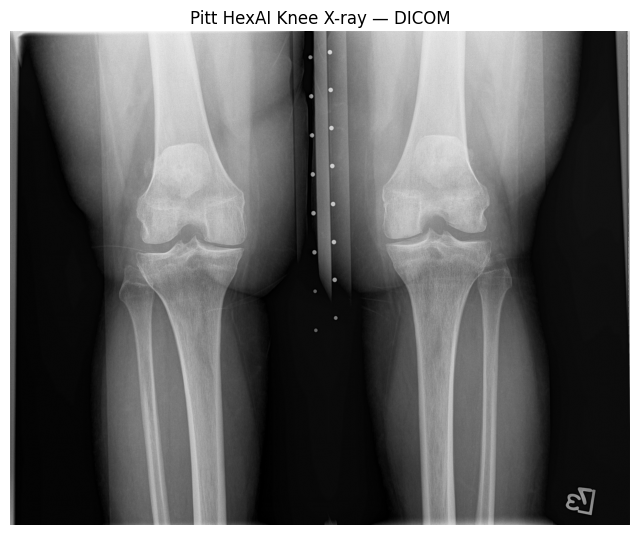

Minimum: 67.0
Maximum: 246.0


In [65]:
import matplotlib.pyplot as plt
import numpy as np

xray_array = ds.pixel_array.astype(np.float32)

plt.figure(figsize=(8, 8))
plt.imshow(xray_array, cmap="gray")
plt.axis("off")
plt.title("Pitt HexAI Knee X-ray — DICOM")
plt.show()

print("Minimum:", xray_array.min())
print("Maximum:", xray_array.max())

In [66]:
import gzip
from pathlib import Path

gz_path = TEST_DIR / gz_files[0]

print("GZ file:")
print(gz_path)

print("File size:",
      round(gz_path.stat().st_size / 1024, 2),
      "KB")

with gzip.open(gz_path, "rb") as f:
    raw = f.read(100)

print("\nFirst 100 bytes:")
print(raw)

GZ file:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/test_files/data/KneeSample/Annotations/9871807.nii.gz
File size: 40.73 KB

First 100 bytes:
b'\\\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00r\x00\x03\x00\xbe\t\x00\x08\x01\x00\x01\x00\x01\x00\x01\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x10\x00\x00\x00\x00\x00\x80?{\x14.>{\x14.>\x00\x00\x80?\x00\x00\x00\x00\x00\x00\x00\x00'


In [67]:
import gzip

with gzip.open(gz_path, "rb") as f:
    data = f.read()

print("Decompressed size:",
      len(data),
      "bytes")

print("\nFirst 200 bytes:")
print(data[:200])

Decompressed size: 10215776 bytes

First 200 bytes:
b'\\\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00r\x00\x03\x00\xbe\t\x00\x08\x01\x00\x01\x00\x01\x00\x01\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x10\x00\x00\x00\x00\x00\x80?{\x14.>{\x14.>\x00\x00\x80?\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xb0C\x00\x00\x80?\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'


In [68]:
LABELS_FILE = PITT_DIR / "bonyanatomy" / "labels.py"

print("File:", LABELS_FILE)
print("Exists:", LABELS_FILE.exists())

if LABELS_FILE.exists():
    print("\n========== labels.py ==========\n")
    print(LABELS_FILE.read_text(errors="ignore"))

File: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/bonyanatomy/labels.py
Exists: True

========== labels.py ==========

from dataclasses import dataclass

@dataclass
class KneeAnatomy:
    classes = {
        0: "Background",
        1: "R Patella",
        2: "R Femur",
        3: "R Tibia",
        4: "R Fibula",
        5: "L Patella",
        6: "L Femur",
        7: "L Tibia",
        8: "L Fibula"
    }

    def get_class(self, class_name):
        self.classes[class_name]

    def get_num_classes(self):
        return len(self.classes)

@dataclass
class HipAnatomy:
    classes = {
        0: "Background",
        1: "R Acetabulum",
        2: "L Acetabulum",
        3: "R Ilium, Ischium, and Pubis",
        4: "L Ilium, Ischium, and Pubis",
        5: "R Femur",
        6: "L Femur"
    }

    def get_class(self, class_name):
        self.classes[class_name]

    def get_num_classes(self):
        return len(self.classes)



In [69]:
DATASET_FILE = PITT_DIR / "bonyanatomy" / "dataset.py"

print("File:", DATASET_FILE)
print("Exists:", DATASET_FILE.exists())

if DATASET_FILE.exists():
    print("\n========== dataset.py ==========\n")
    text = DATASET_FILE.read_text(errors="ignore")
    print(text[:20000])

File: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/bonyanatomy/dataset.py
Exists: True

========== dataset.py ==========

import cv2
import pydicom
import nibabel
import numpy as np
import os

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold


class BonyAnatomyJointSegmentationDataset(Dataset):
    def __init__(self, root_dir, ids, transforms=None):
        self.root_dir = root_dir
        self.pids = ids
        self.transforms = transforms

    def load_dicom(self, path):
        dicom_img = pydicom.dcmread(path)
        return dicom_img.pixel_array.astype(np.float32)

    def load_nii(self, path):
        nii_annot = nibabel.load(path)
        nii_annot_data = nii_annot.get_fdata()

        if len(nii_annot_data.shape) == 3 and nii_annot_data.shape[-1] > 1:
            if nii_annot_data.shape[-1] == 2:
                nii_annot_data = nii_annot_data[:, :, 1]
            else:
                nii_annot

In [70]:
PIPELINE_FILE = PITT_DIR / "bonyanatomy" / "pipeline.py"

print("File:", PIPELINE_FILE)
print("Exists:", PIPELINE_FILE.exists())

if PIPELINE_FILE.exists():
    print("\n========== pipeline.py ==========\n")
    text = PIPELINE_FILE.read_text(errors="ignore")
    print(text[:20000])

File: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/bonyanatomy/pipeline.py
Exists: True

========== pipeline.py ==========

import os
import pandas as pd
import numpy as np
import copy
import json

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

from segmentation_models_pytorch import utils as smp_utils

class TrainingPipeline:
    def __init__(self, name,  training_config, sampler=None, stratify_on=None):
        self.name = name
        self.training_config = training_config
        self.stratify_on = stratify_on
        self.sampler = sampler
        self.save_dir = f"{self.training_config.outdir}/{self.name}/"
        
        self.load_datasources()
        os.makedirs(self.save_dir, exist_ok=True)

    def load_datasources(self):
        train_data = pd.read_csv(self.training_config.train_set)
        valid_data = pd.read_csv(self.training_config.valid_set)
        test_data = pd.read_csv(self.training_

In [71]:
!pip -q install pydicom nibabel SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.4 MB/s eta 0:00:00


In [72]:
from pathlib import Path

PITT_DIR = Path(
    "/content/MedVisionAI/"
    "AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation"
)

labels_file = PITT_DIR / "bonyanatomy" / "labels.py"

print("=" * 60)
print("PITT LABEL DEFINITIONS")
print("=" * 60)

print(labels_file.read_text(errors="ignore"))

PITT LABEL DEFINITIONS
from dataclasses import dataclass

@dataclass
class KneeAnatomy:
    classes = {
        0: "Background",
        1: "R Patella",
        2: "R Femur",
        3: "R Tibia",
        4: "R Fibula",
        5: "L Patella",
        6: "L Femur",
        7: "L Tibia",
        8: "L Fibula"
    }

    def get_class(self, class_name):
        self.classes[class_name]

    def get_num_classes(self):
        return len(self.classes)

@dataclass
class HipAnatomy:
    classes = {
        0: "Background",
        1: "R Acetabulum",
        2: "L Acetabulum",
        3: "R Ilium, Ischium, and Pubis",
        4: "L Ilium, Ischium, and Pubis",
        5: "R Femur",
        6: "L Femur"
    }

    def get_class(self, class_name):
        self.classes[class_name]

    def get_num_classes(self):
        return len(self.classes)



In [73]:
dataset_file = PITT_DIR / "bonyanatomy" / "dataset.py"

print("=" * 60)
print("PITT DATASET LOADER")
print("=" * 60)

text = dataset_file.read_text(errors="ignore")

print(text[:30000])

PITT DATASET LOADER
import cv2
import pydicom
import nibabel
import numpy as np
import os

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold


class BonyAnatomyJointSegmentationDataset(Dataset):
    def __init__(self, root_dir, ids, transforms=None):
        self.root_dir = root_dir
        self.pids = ids
        self.transforms = transforms

    def load_dicom(self, path):
        dicom_img = pydicom.dcmread(path)
        return dicom_img.pixel_array.astype(np.float32)

    def load_nii(self, path):
        nii_annot = nibabel.load(path)
        nii_annot_data = nii_annot.get_fdata()

        if len(nii_annot_data.shape) == 3 and nii_annot_data.shape[-1] > 1:
            if nii_annot_data.shape[-1] == 2:
                nii_annot_data = nii_annot_data[:, :, 1]
            else:
                nii_annot_data = nii_annot_data[:, :, nii_annot_data.shape[-1]//2]

            nii_annot_data = np.expand_dims(nii_annot_data, axis=-1)


  

In [74]:
pipeline_file = PITT_DIR / "bonyanatomy" / "pipeline.py"

print("=" * 60)
print("PITT PIPELINE")
print("=" * 60)

text = pipeline_file.read_text(errors="ignore")

print(text[:30000])

PITT PIPELINE
import os
import pandas as pd
import numpy as np
import copy
import json

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

from segmentation_models_pytorch import utils as smp_utils

class TrainingPipeline:
    def __init__(self, name,  training_config, sampler=None, stratify_on=None):
        self.name = name
        self.training_config = training_config
        self.stratify_on = stratify_on
        self.sampler = sampler
        self.save_dir = f"{self.training_config.outdir}/{self.name}/"
        
        self.load_datasources()
        os.makedirs(self.save_dir, exist_ok=True)

    def load_datasources(self):
        train_data = pd.read_csv(self.training_config.train_set)
        valid_data = pd.read_csv(self.training_config.valid_set)
        test_data = pd.read_csv(self.training_config.test_set)

        self.train_split = self.training_config.dataset(self.training_config.imaging_root, train_data.id, self.training_co

In [75]:
import gzip
from pathlib import Path

gz_path = TEST_DIR / gz_files[0]

with gzip.open(gz_path, "rb") as f:
    data = f.read()

print("GZ file:", gz_path)
print("Decompressed bytes:", len(data))

print("\nFirst 500 bytes:")
print(data[:500])

GZ file: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/test_files/data/KneeSample/Annotations/9871807.nii.gz
Decompressed bytes: 10215776

First 500 bytes:
b'\\\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00r\x00\x03\x00\xbe\t\x00\x08\x01\x00\x01\x00\x01\x00\x01\x00\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x10\x00\x00\x00\x00\x00\x80?{\x14.>{\x14.>\x00\x00\x80?\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xb0C\x00\x00\x80?\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [76]:
import gzip

with gzip.open(gz_path, "rb") as f:
    header = f.read(348)

print("Header length:", len(header))

# NIfTI-1 stores sizeof_hdr = 348 in the first 4 bytes
if len(header) >= 4:
    size_header = int.from_bytes(
        header[:4],
        byteorder="little",
        signed=True
    )

    print("Possible NIfTI header size:", size_header)

    if size_header == 348:
        print("✅ This appears to be a NIfTI-1 file.")
    else:
        print("⚠️ Not identified as standard NIfTI-1.")

Header length: 348
Possible NIfTI header size: 348
✅ This appears to be a NIfTI-1 file.


In [77]:
import gzip
import struct

with gzip.open(gz_path, "rb") as f:
    data = f.read()

print("Total decompressed bytes:", len(data))

# Check common file signatures
signatures = {
    "NIfTI-1": data[:4] == struct.pack("<i", 348),
    "NIfTI-2": data[:8] == b"\x6e\x2b\x31\x00",
    "DICOM": data[:132].startswith(b"DICM"),
    "PNG": data.startswith(b"\x89PNG"),
    "JPEG": data.startswith(b"\xff\xd8\xff"),
}

print("\n===== FORMAT CHECK =====")

for fmt, detected in signatures.items():
    print(f"{fmt}: {detected}")

Total decompressed bytes: 10215776

===== FORMAT CHECK =====
NIfTI-1: True
NIfTI-2: False
DICOM: False
PNG: False
JPEG: False


In [78]:
import pandas as pd
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    csv_name = csv_files[0]

    with z.open(csv_name) as f:
        df_meta = pd.read_csv(f)

print("Shape:", df_meta.shape)

print("\nColumns:")
for col in df_meta.columns:
    print(" -", col)

print("\n===== FIRST 20 ROWS =====")
display(df_meta.head(20))

Shape: (100, 4)

Columns:
 - id
 - V00AGE
 - P02SEX
 - P02RACE

===== FIRST 20 ROWS =====


,id,V00AGE,P02SEX,P02RACE
0,9634146,53,1: Male,1: White or Caucasian
1,9052978,70,1: Male,1: White or Caucasian
2,9595419,51,1: Male,1: White or Caucasian
3,9610229,53,2: Female,1: White or Caucasian
4,9772637,67,1: Male,2: Black or African American
5,9154516,78,2: Female,1: White or Caucasian
6,9380143,59,2: Female,2: Black or African American
7,9648234,64,2: Female,2: Black or African American
8,9646687,76,1: Male,2: Black or African American
9,9301222,51,2: Female,1: White or Caucasian


In [79]:
print("===== DICOM BASENAMES =====")

for x in dcm_files[:30]:
    print(Path(x).stem)

print("\n===== GZ BASENAMES =====")

for x in gz_files[:30]:
    print(Path(x).stem)

===== DICOM BASENAMES =====
9834586
9052978
9732525
9125488
9816736
9528955
9873057
9299721
9011420
9011661
9908089
9333528
9701165
9446305
9589653
9882107
9289212
9573142
9158313
9871807
9026416
9380143
9496443
9016304
9184192
9772637
9916140
9330147
9947321
9923619

===== GZ BASENAMES =====
9871807.nii
9033275.nii
9866764.nii
9154516.nii
9930368.nii
9333528.nii
9593719.nii
9299721.nii
9184192.nii
9287216.nii
9610229.nii
9648234.nii
9882107.nii
9446305.nii
9752895.nii
9816736.nii
9970801.nii
9380143.nii
9371094.nii
9096724.nii
9004184.nii
9709990.nii
9330147.nii
9011661.nii
9049729.nii
9589653.nii
9569715.nii
9176893.nii
9697904.nii
9907090.nii


In [80]:
dcm_stems = {
    Path(x).stem.lower(): x
    for x in dcm_files
}

gz_stems = {
    Path(x).stem.lower(): x
    for x in gz_files
}

common = sorted(
    set(dcm_stems.keys()) &
    set(gz_stems.keys())
)

print("Exact common basenames:", len(common))

for x in common[:30]:
    print("✅", x)

Exact common basenames: 0


In [81]:
from pathlib import Path
import pandas as pd

# Extracted Pitt knee dataset
KNEE_DIR = EXTRACT_DIR

# Find DICOMs
dcm_files = list(KNEE_DIR.rglob("*.dcm"))

# Find NIfTI annotations
nii_files = [
    p for p in KNEE_DIR.rglob("*")
    if p.name.lower().endswith(".nii.gz")
]

print("DICOM files:", len(dcm_files))
print("NIfTI annotation files:", len(nii_files))

# Create ID dictionaries
dcm_by_id = {
    p.stem: p
    for p in dcm_files
}

nii_by_id = {
    p.name[:-7]: p   # removes ".nii.gz"
    for p in nii_files
}

print("\nDICOM IDs:", len(dcm_by_id))
print("NIfTI IDs:", len(nii_by_id))

# Match by ID
common_ids = sorted(
    set(dcm_by_id.keys()) &
    set(nii_by_id.keys())
)

print("\nMatched pairs:", len(common_ids))

pairs = []

for patient_id in common_ids:
    pairs.append({
        "id": patient_id,
        "image_path": str(dcm_by_id[patient_id]),
        "mask_path": str(nii_by_id[patient_id])
    })

df_pairs = pd.DataFrame(pairs)

print("\n===== FIRST PAIRS =====")
display(df_pairs.head(10))

DICOM files: 100
NIfTI annotation files: 100

DICOM IDs: 100
NIfTI IDs: 100

Matched pairs: 100

===== FIRST PAIRS =====


,id,image_path,mask_path
0,9004184,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
1,9011420,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
2,9011661,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
3,9016304,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
4,9026416,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
5,9033275,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
6,9048979,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
7,9049729,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
8,9052708,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
9,9052978,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...


In [82]:
PROJECT = Path("/content/MedVision_AI_Member1_2_ActualData")

DATA_DIR = PROJECT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

SEG_CSV = DATA_DIR / "pitt_knee_pairs.csv"

df_pairs.to_csv(SEG_CSV, index=False)

print("✅ Saved:")
print(SEG_CSV)

print("\nTotal pairs:", len(df_pairs))

✅ Saved:
/content/MedVision_AI_Member1_2_ActualData/data/pitt_knee_pairs.csv

Total pairs: 100


In [83]:
import nibabel as nib
import numpy as np

if len(df_pairs) == 0:
    raise ValueError(
        "❌ No DICOM/NIfTI pairs found. "
        "Check the extracted dataset."
    )

row = df_pairs.iloc[0]

image_path = Path(row["image_path"])
mask_path = Path(row["mask_path"])

print("Image:")
print(image_path)

print("\nMask:")
print(mask_path)

nii = nib.load(str(mask_path))

mask_data = np.asarray(nii.dataobj)

print("\n===== NIFTI INFORMATION =====")
print("Shape:", mask_data.shape)
print("Data type:", mask_data.dtype)
print("Affine shape:", nii.affine.shape)

unique_values = np.unique(mask_data)

print("\nUnique values:")
print(unique_values)

print("\nNumber of unique values:", len(unique_values))

Image:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample/data/KneeSample/Images/9004184.dcm

Mask:
/content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample/data/KneeSample/Annotations/9004184.nii.gz

===== NIFTI INFORMATION =====
Shape: (4274, 3482, 1)
Data type: uint16
Affine shape: (4, 4)

Unique values:
[0 1 2 3 4 5 6 7 8]

Number of unique values: 9


In [84]:
LABELS = {
    0: "Background",
    1: "R Patella",
    2: "R Femur",
    3: "R Tibia",
    4: "R Fibula",
    5: "L Patella",
    6: "L Femur",
    7: "L Tibia",
    8: "L Fibula"
}

print("===== DETECTED LABELS =====")

for value in unique_values:

    value_int = int(value)

    if value_int in LABELS:
        print(
            f"{value_int}: {LABELS[value_int]}"
        )
    else:
        print(
            f"{value_int}: ⚠️ UNKNOWN LABEL"
        )

===== DETECTED LABELS =====
0: Background
1: R Patella
2: R Femur
3: R Tibia
4: R Fibula
5: L Patella
6: L Femur
7: L Tibia
8: L Fibula


In [85]:
import pydicom
import numpy as np

ds = pydicom.dcmread(str(image_path))

xray = ds.pixel_array

print("===== DICOM =====")
print("Rows:", ds.Rows)
print("Columns:", ds.Columns)
print("Pixel shape:", xray.shape)
print("Data type:", xray.dtype)

print("\nMinimum:", xray.min())
print("Maximum:", xray.max())

===== DICOM =====
Rows: 3482
Columns: 4274
Pixel shape: (3482, 4274)
Data type: uint16

Minimum: 65
Maximum: 244


In [88]:
# CELL 76 — Self-contained X-ray / NIfTI dimension correction

import numpy as np
import nibabel as nib
import pydicom
from pathlib import Path

# ---------------------------------------------------------
# 1. Find DICOM files
# ---------------------------------------------------------
dcm_files = list(EXTRACT_DIR.rglob("*.dcm"))

# Find NIfTI files
nii_files = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.name.lower().endswith(".nii.gz")
]

print("DICOM files found:", len(dcm_files))
print("NIfTI files found:", len(nii_files))

# ---------------------------------------------------------
# 2. Match files using the patient/image ID
# ---------------------------------------------------------
dcm_by_id = {p.stem: p for p in dcm_files}

# Remove ".nii.gz" correctly
nii_by_id = {
    p.name[:-7]: p
    for p in nii_files
}

common_ids = sorted(
    set(dcm_by_id.keys()) & set(nii_by_id.keys())
)

print("Matched pairs:", len(common_ids))

if len(common_ids) == 0:
    raise ValueError("❌ No matching DICOM/NIfTI pairs found.")

# ---------------------------------------------------------
# 3. Select first matched pair
# ---------------------------------------------------------
patient_id = common_ids[0]

sample_image_path = dcm_by_id[patient_id]
sample_mask_path = nii_by_id[patient_id]

print("\nSelected ID:", patient_id)
print("X-ray:", sample_image_path)
print("Mask:", sample_mask_path)

# ---------------------------------------------------------
# 4. Load X-ray
# ---------------------------------------------------------
ds = pydicom.dcmread(str(sample_image_path))
xray = ds.pixel_array

# ---------------------------------------------------------
# 5. Load NIfTI mask
# ---------------------------------------------------------
nii = nib.load(str(sample_mask_path))
mask = np.asarray(nii.dataobj)

print("\n===== ORIGINAL SHAPES =====")
print("X-ray:", xray.shape)
print("Mask:", mask.shape)

# ---------------------------------------------------------
# 6. Remove singleton dimension
# ---------------------------------------------------------
mask = np.squeeze(mask)

print("\nMask after squeeze:", mask.shape)

# ---------------------------------------------------------
# 7. Correct orientation if dimensions are reversed
# ---------------------------------------------------------
if mask.shape == xray.shape:
    print("✅ Mask dimensions already match X-ray.")

elif mask.shape == xray.shape[::-1]:
    mask = mask.T
    print("✅ Mask transposed to match X-ray.")

else:
    print("❌ Unexpected dimensions.")
    print("X-ray:", xray.shape)
    print("Mask:", mask.shape)

# ---------------------------------------------------------
# 8. Final check
# ---------------------------------------------------------
print("\n===== FINAL DIMENSION COMPARISON =====")
print("X-ray:", xray.shape)
print("Mask:", mask.shape)

if xray.shape == mask.shape:
    print("✅ PERFECT MATCH — ready for overlay verification.")
else:
    print("⚠️ Dimensions still do not match.")
    print("DO NOT train yet.")

DICOM files found: 100
NIfTI files found: 100
Matched pairs: 100

Selected ID: 9004184
X-ray: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample/data/KneeSample/Images/9004184.dcm
Mask: /content/MedVisionAI/AI_Fairness_in_Hip_and_Knee_Bony_Anatomy_Segmentation/Sample_Dataset/knee_sample/data/KneeSample/Annotations/9004184.nii.gz

===== ORIGINAL SHAPES =====
X-ray: (3482, 4274)
Mask: (4274, 3482, 1)

Mask after squeeze: (4274, 3482)
✅ Mask transposed to match X-ray.

===== FINAL DIMENSION COMPARISON =====
X-ray: (3482, 4274)
Mask: (3482, 4274)
✅ PERFECT MATCH — ready for overlay verification.


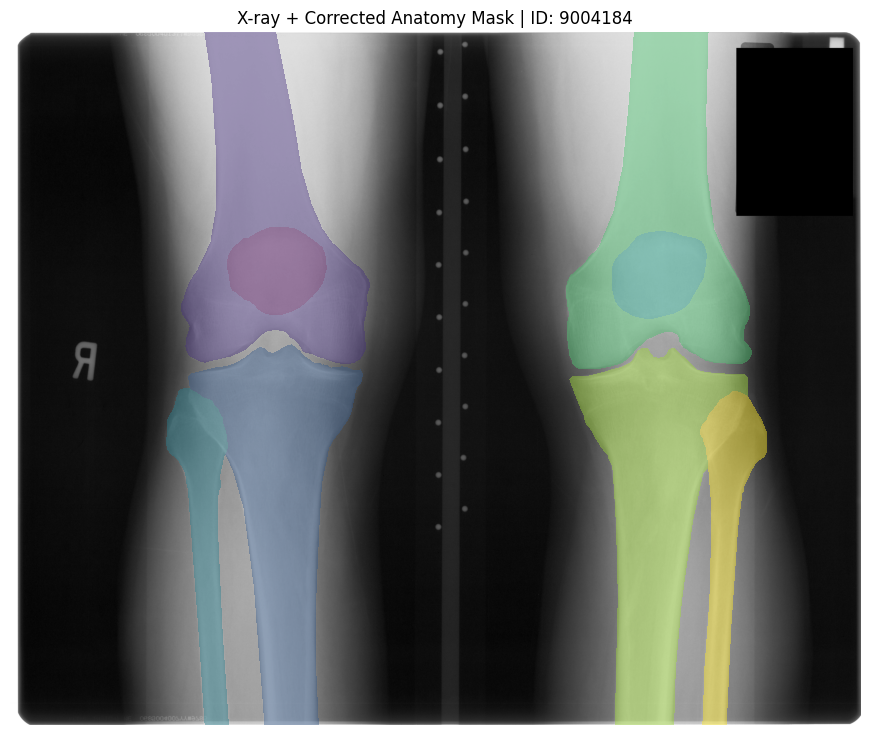

In [89]:
# CELL 77 — Verify the corrected mask visually

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(xray, cmap="gray")

# Show only non-background mask
masked = np.ma.masked_where(mask == 0, mask)

plt.imshow(
    masked,
    alpha=0.45,
    interpolation="nearest"
)

plt.title(f"X-ray + Corrected Anatomy Mask | ID: {patient_id}")
plt.axis("off")
plt.show()

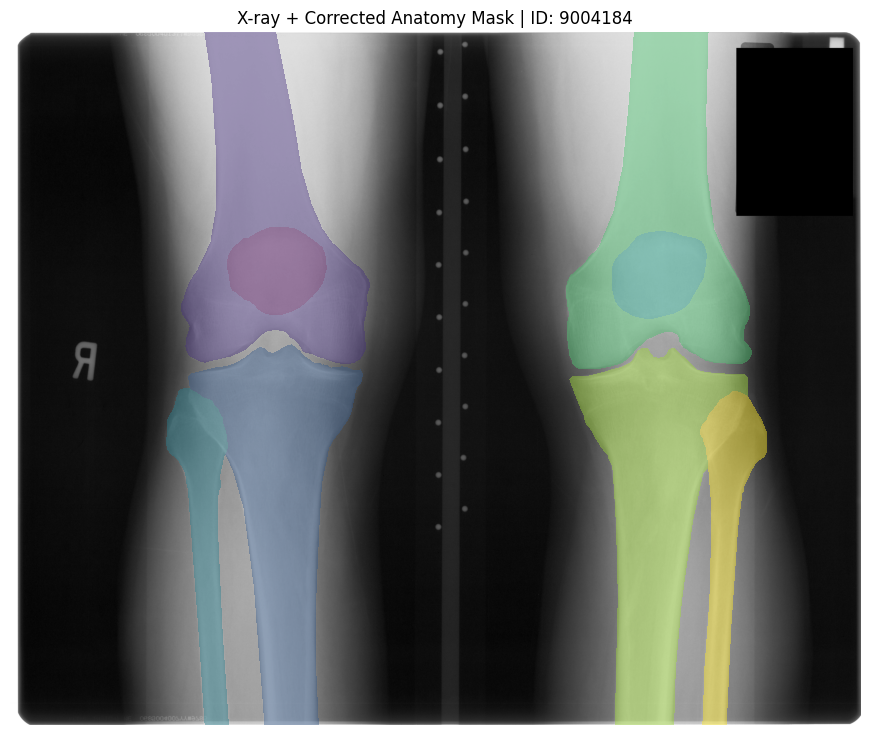

In [90]:
# CELL 77 — Visual overlay verification

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(xray, cmap="gray")

# Display anatomy mask while hiding background
masked = np.ma.masked_where(mask == 0, mask)

plt.imshow(
    masked,
    alpha=0.45,
    interpolation="nearest"
)

plt.title(f"X-ray + Corrected Anatomy Mask | ID: {patient_id}")
plt.axis("off")
plt.show()

In [91]:
# CELL 78 — Verify anatomy labels

import numpy as np

unique_values, counts = np.unique(mask, return_counts=True)

print("===== MASK LABELS =====")

for value, count in zip(unique_values, counts):
    print(f"Label {int(value)}: {count:,} pixels")

print("\n===== LABEL MEANINGS =====")

LABELS = {
    0: "Background",
    1: "R Patella",
    2: "R Femur",
    3: "R Tibia",
    4: "R Fibula",
    5: "L Patella",
    6: "L Femur",
    7: "L Tibia",
    8: "L Fibula"
}

for value in unique_values:
    value = int(value)
    print(f"{value}: {LABELS.get(value, 'UNKNOWN')}")

===== MASK LABELS =====
Label 0: 10,907,486 pixels
Label 1: 168,000 pixels
Label 2: 754,426 pixels
Label 3: 788,842 pixels
Label 4: 268,355 pixels
Label 5: 165,200 pixels
Label 6: 770,200 pixels
Label 7: 788,225 pixels
Label 8: 271,334 pixels

===== LABEL MEANINGS =====
0: Background
1: R Patella
2: R Femur
3: R Tibia
4: R Fibula
5: L Patella
6: L Femur
7: L Tibia
8: L Fibula


In [92]:
# CELL 79 — Validate all labels

valid_labels = set(range(9))
detected_labels = set(int(x) for x in np.unique(mask))

invalid_labels = detected_labels - valid_labels

print("Detected labels:", sorted(detected_labels))
print("Expected labels:", sorted(valid_labels))

if not invalid_labels:
    print("✅ ALL LABELS ARE VALID (0–8)")
else:
    print("❌ INVALID LABELS FOUND:", sorted(invalid_labels))

Detected labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Expected labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
✅ ALL LABELS ARE VALID (0–8)


In [93]:
# CELL 80 — Create final Member 2 training CSV

from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/MedVision_AI_Member1_2_ActualData")
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

training_records = []

for patient_id in common_ids:
    training_records.append({
        "id": patient_id,
        "image_path": str(dcm_by_id[patient_id]),
        "mask_path": str(nii_by_id[patient_id])
    })

df_training = pd.DataFrame(training_records)

csv_path = DATA_DIR / "pitt_knee_training.csv"
df_training.to_csv(csv_path, index=False)

print("✅ Training CSV created")
print("Path:", csv_path)
print("Number of image-mask pairs:", len(df_training))

display(df_training.head())

✅ Training CSV created
Path: /content/MedVision_AI_Member1_2_ActualData/data/pitt_knee_training.csv
Number of image-mask pairs: 100


,id,image_path,mask_path
0,9004184,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
1,9011420,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
2,9011661,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
3,9016304,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...
4,9026416,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...,/content/MedVisionAI/AI_Fairness_in_Hip_and_Kn...


In [94]:
# CELL 81 — Install required packages for Member 2

!pip -q install nibabel pydicom

In [95]:
# CELL 82 — Check GPU

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not detected. Enable GPU in Colab:")
    print("Runtime → Change runtime type → Hardware accelerator → GPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [98]:
# CELL 83 — Corrected 9-class ResNet18 U-Net

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

NUM_CLASSES = 9


class ResNet18UNet(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # -------------------------
        # Encoder
        # -------------------------
        self.enc1 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.pool1 = backbone.maxpool

        self.enc2 = backbone.layer1      # 64
        self.enc3 = backbone.layer2      # 128
        self.enc4 = backbone.layer3      # 256
        self.enc5 = backbone.layer4      # 512

        # -------------------------
        # Decoder
        # -------------------------

        self.up4 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec4 = self.conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = self.conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = self.conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 64, kernel_size=2, stride=2
        )
        self.dec1 = self.conv_block(128, 64)

        # Final upsampling:
        # encoder output is 1/4 resolution,
        # so two ×2 operations are needed to reach input resolution.
        self.up0 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )

        self.final = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1)
        )

    @staticmethod
    def conv_block(in_channels, out_channels):

        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        # -------------------------
        # Encoder
        # -------------------------

        e1 = self.enc1(x)       # 192 × 192
        p1 = self.pool1(e1)     # 96 × 96

        e2 = self.enc2(p1)      # 96 × 96
        e3 = self.enc3(e2)      # 48 × 48
        e4 = self.enc4(e3)      # 24 × 24
        e5 = self.enc5(e4)      # 12 × 12

        # -------------------------
        # Decoder
        # -------------------------

        d4 = self.up4(e5)       # 24 × 24
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)       # 48 × 48
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)       # 96 × 96
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)       # 192 × 192
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # 192 → 384
        out = self.up0(d1)

        # Final segmentation
        out = self.final(out)

        return out


# Create model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ResNet18UNet(NUM_CLASSES).to(device)

print("✅ Corrected model created")
print("Classes:", NUM_CLASSES)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

✅ Corrected model created
Classes: 9
Device: cuda
GPU: Tesla T4


In [99]:
# CELL 84 — Test corrected model

test_input = torch.randn(
    1, 3, 384, 384
).to(device)

with torch.no_grad():
    test_output = model(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)

assert test_output.shape == (
    1,
    NUM_CLASSES,
    384,
    384
), "❌ Unexpected model output shape"

print("✅ MODEL SHAPE TEST PASSED")

Input shape : torch.Size([1, 3, 384, 384])
Output shape: torch.Size([1, 9, 384, 384])
✅ MODEL SHAPE TEST PASSED


In [100]:
# CELL 85 — Member 2 Dataset Loader

import pandas as pd
import numpy as np
import nibabel as nib
import pydicom

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF


IMAGE_SIZE = 384


class KneeAnatomyDataset(Dataset):

    def __init__(self, dataframe, image_size=IMAGE_SIZE):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # -----------------------------
        # Load DICOM X-ray
        # -----------------------------
        ds = pydicom.dcmread(row["image_path"])
        image = ds.pixel_array.astype(np.float32)

        # Correct MONOCHROME1 images
        if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
            image = image.max() - image

        # Normalize
        image -= image.min()

        if image.max() > 0:
            image /= image.max()

        image = (image * 255).astype(np.uint8)

        # Grayscale → RGB
        image = Image.fromarray(image).convert("RGB")

        # -----------------------------
        # Load NIfTI mask
        # -----------------------------
        nii = nib.load(row["mask_path"])
        mask = np.asarray(nii.dataobj)

        # Remove singleton dimension
        mask = np.squeeze(mask)

        # Correct orientation
        expected_shape = image.size[::-1]

        if mask.shape == expected_shape:
            pass

        elif mask.shape == expected_shape[::-1]:
            mask = mask.T

        else:
            raise ValueError(
                f"Shape mismatch for {row['id']}: "
                f"image={expected_shape}, mask={mask.shape}"
            )

        # -----------------------------
        # Resize
        # -----------------------------
        image = image.resize(
            (self.image_size, self.image_size),
            Image.Resampling.BILINEAR
        )

        # IMPORTANT:
        # NEAREST preserves class labels 0–8
        mask = Image.fromarray(mask.astype(np.uint8))

        mask = mask.resize(
            (self.image_size, self.image_size),
            Image.Resampling.NEAREST
        )

        # -----------------------------
        # Convert image to tensor
        # -----------------------------
        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        # -----------------------------
        # Convert mask to tensor
        # -----------------------------
        mask = torch.from_numpy(
            np.array(mask, dtype=np.int64)
        )

        return image, mask


print("✅ Dataset class created")

✅ Dataset class created


In [101]:
# CELL 86 — Train / Validation Split

from sklearn.model_selection import train_test_split

CSV_PATH = (
    "/content/MedVision_AI_Member1_2_ActualData/"
    "data/pitt_knee_training.csv"
)

df = pd.read_csv(CSV_PATH)

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train_dataset = KneeAnatomyDataset(train_df)
val_dataset = KneeAnatomyDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("===== DATASET SPLIT =====")
print("Total images :", len(df))
print("Training     :", len(train_df))
print("Validation   :", len(val_df))
print("Batch size   :", 4)
print("Image size   :", IMAGE_SIZE)

===== DATASET SPLIT =====
Total images : 100
Training     : 80
Validation   : 20
Batch size   : 4
Image size   : 384


In [102]:
# CELL 87 — Test real dataset sample

sample_image, sample_mask = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Mask tensor shape :", sample_mask.shape)

print(
    "Mask labels:",
    torch.unique(sample_mask).cpu().numpy()
)

assert sample_image.shape == (3, 384, 384)
assert sample_mask.shape == (384, 384)

print("✅ REAL DATASET SAMPLE TEST PASSED")

Image tensor shape: torch.Size([3, 384, 384])
Mask tensor shape : torch.Size([384, 384])
Mask labels: [0 1 2 3 4 5 6 7 8]
✅ REAL DATASET SAMPLE TEST PASSED


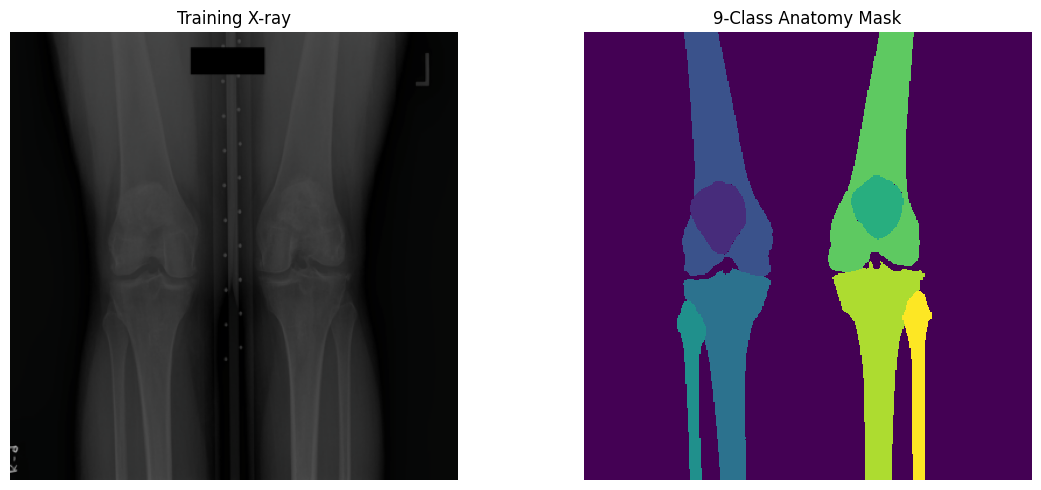

In [103]:
# CELL 88 — Visualize training sample

import matplotlib.pyplot as plt

# Convert normalized image back approximately for display
display_image = sample_image.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

display_image = display_image * std + mean
display_image = np.clip(display_image, 0, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(display_image)
plt.title("Training X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_mask.numpy(), interpolation="nearest")
plt.title("9-Class Anatomy Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [104]:
# CELL 89 — Multi-class Dice Loss

import torch
import torch.nn.functional as F


def multiclass_dice_loss(
    logits,
    targets,
    num_classes=NUM_CLASSES,
    smooth=1.0
):
    """
    Multi-class Dice loss.

    logits:
        [B, C, H, W]

    targets:
        [B, H, W]
    """

    probs = F.softmax(logits, dim=1)

    targets_one_hot = F.one_hot(
        targets,
        num_classes=num_classes
    )

    targets_one_hot = targets_one_hot.permute(
        0, 3, 1, 2
    ).float()

    dims = (0, 2, 3)

    intersection = (
        probs * targets_one_hot
    ).sum(dims)

    denominator = (
        probs.sum(dims) +
        targets_one_hot.sum(dims)
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    # Ignore background when calculating loss
    dice_foreground = dice[1:]

    return 1.0 - dice_foreground.mean()


print("✅ Dice loss created")

✅ Dice loss created


In [105]:
# CELL 90 — Combined segmentation loss

class CombinedLoss(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
        dice_weight=0.5
    ):
        super().__init__()

        self.ce = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
        self.num_classes = num_classes

    def forward(self, logits, targets):

        ce_loss = self.ce(logits, targets)

        dice_loss = multiclass_dice_loss(
            logits,
            targets,
            self.num_classes
        )

        total_loss = (
            (1 - self.dice_weight) * ce_loss
            + self.dice_weight * dice_loss
        )

        return total_loss


criterion = CombinedLoss(
    num_classes=NUM_CLASSES,
    dice_weight=0.5
)

print("✅ Combined Cross-Entropy + Dice loss ready")

✅ Combined Cross-Entropy + Dice loss ready


In [106]:
# CELL 91 — Optimizer and learning-rate scheduler

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("✅ Optimizer:", type(optimizer).__name__)
print("Learning rate:", 2e-4)

✅ Optimizer: AdamW
Learning rate: 0.0002


In [107]:
# CELL 92 — Dice and IoU metrics

def calculate_metrics(
    logits,
    targets,
    num_classes=NUM_CLASSES
):

    predictions = torch.argmax(
        logits,
        dim=1
    )

    dice_scores = []
    iou_scores = []

    for cls in range(1, num_classes):

        pred_cls = predictions == cls
        target_cls = targets == cls

        intersection = (
            pred_cls & target_cls
        ).sum().float()

        pred_area = pred_cls.sum().float()
        target_area = target_cls.sum().float()

        union = (
            pred_cls | target_cls
        ).sum().float()

        dice = (
            (2 * intersection + 1e-6)
            / (pred_area + target_area + 1e-6)
        )

        iou = (
            (intersection + 1e-6)
            / (union + 1e-6)
        )

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

    return (
        float(np.mean(dice_scores)),
        float(np.mean(iou_scores))
    )


print("✅ Dice and IoU metrics ready")

✅ Dice and IoU metrics ready


In [108]:
# CELL 93 — Train Member 2 anatomy segmentation model

import time
from pathlib import Path

EPOCHS = 20

MODEL_DIR = Path(
    "/content/MedVision_AI_Member1_2_ActualData/models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "anatomy_resnet18_unet_9class.pt"
)

best_val_dice = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}


for epoch in range(EPOCHS):

    start_time = time.time()

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_loss = 0.0

    for images, masks in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

    train_loss = (
        running_loss /
        len(train_loader.dataset)
    )

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_running_loss = 0.0

    all_dice = []
    all_iou = []

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            val_running_loss += (
                loss.item() * images.size(0)
            )

            dice, iou = calculate_metrics(
                outputs,
                masks
            )

            all_dice.append(dice)
            all_iou.append(iou)

    val_loss = (
        val_running_loss /
        len(val_loader.dataset)
    )

    val_dice = float(np.mean(all_dice))
    val_iou = float(np.mean(all_iou))

    scheduler.step(val_dice)

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_dice > best_val_dice:

        best_val_dice = val_dice

        torch.save(
            {
                "model_state": model.state_dict(),
                "num_classes": NUM_CLASSES,
                "image_size": IMAGE_SIZE,
                "best_val_dice": best_val_dice,
                "label_names": LABELS
            },
            BEST_MODEL_PATH
        )

        saved = " ⭐ BEST MODEL SAVED"

    else:
        saved = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"Time: {elapsed:.1f}s"
        f"{saved}"
    )


print("\n========================================")
print("✅ TRAINING COMPLETE")
print("========================================")
print("Best validation Dice:", best_val_dice)
print("Model saved to:")
print(BEST_MODEL_PATH)

/usr/local/lib/python3.13/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


Epoch 01/20 | Train Loss: 1.3992 | Val Loss: 1.4994 | Dice: 0.0329 | IoU: 0.0176 | Time: 12.9s ⭐ BEST MODEL SAVED


/usr/local/lib/python3.13/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


Epoch 02/20 | Train Loss: 1.2159 | Val Loss: 1.2208 | Dice: 0.0609 | IoU: 0.0353 | Time: 11.7s ⭐ BEST MODEL SAVED


/usr/local/lib/python3.13/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


...

Epoch 18/20 | Train Loss: 0.4462 | Val Loss: 0.4513 | Dice: 0.8688 | IoU: 0.8039 | Time: 12.5s ⭐ BEST MODEL SAVED


/usr/local/lib/python3.13/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


Epoch 19/20 | Train Loss: 0.4198 | Val Loss: 0.4256 | Dice: 0.9406 | IoU: 0.8899 | Time: 12.5s ⭐ BEST MODEL SAVED


/usr/local/lib/python3.13/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


Epoch 20/20 | Train Loss: 0.3915 | Val Loss: 0.3964 | Dice: 0.9382 | IoU: 0.8856 | Time: 12.3s

✅ TRAINING COMPLETE
Best validation Dice: 0.9406400114297867
Model saved to:
/content/MedVision_AI_Member1_2_ActualData/models/anatomy_resnet18_unet_9class.pt


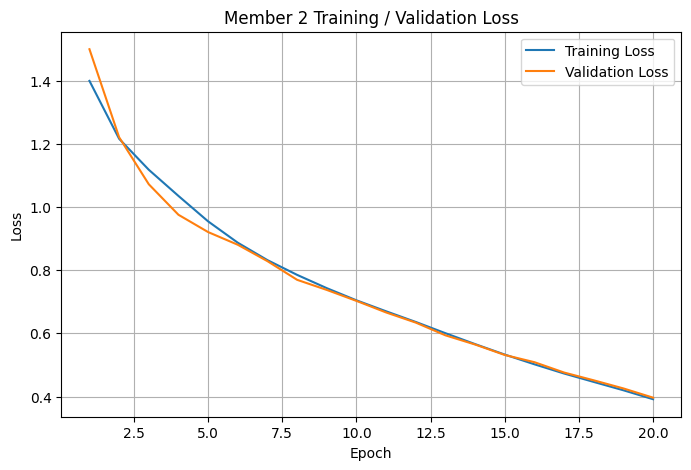

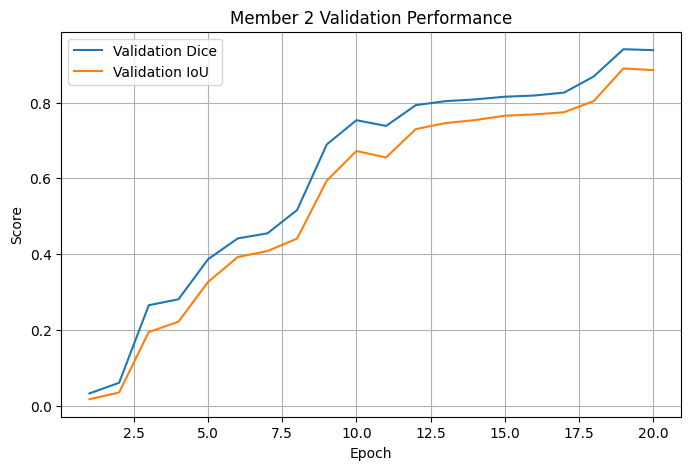

In [109]:
# CELL 94 — Plot training history

import matplotlib.pyplot as plt

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Member 2 Training / Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_dice"],
    label="Validation Dice"
)

plt.plot(
    epochs,
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Member 2 Validation Performance")
plt.legend()
plt.grid(True)

plt.show()

In [110]:
# CELL 95 — Verify Member 2 checkpoint

from pathlib import Path

model_path = Path(
    "/content/MedVision_AI_Member1_2_ActualData/models/"
    "anatomy_resnet18_unet_9class.pt"
)

print("Model exists:", model_path.exists())
print("Model path:", model_path)

if model_path.exists():
    print(
        "Model size:",
        round(model_path.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    print("Number of classes:", checkpoint["num_classes"])
    print("Image size:", checkpoint["image_size"])
    print("Best validation Dice:", checkpoint["best_val_dice"])
    print("Labels:", checkpoint["label_names"])

    print("\n✅ MEMBER 2 MODEL CHECKPOINT VERIFIED")

Model exists: True
Model path: /content/MedVision_AI_Member1_2_ActualData/models/anatomy_resnet18_unet_9class.pt
Model size: 54.8 MB
Number of classes: 9
Image size: 384
Best validation Dice: 0.9406400114297867
Labels: {0: 'Background', 1: 'R Patella', 2: 'R Femur', 3: 'R Tibia', 4: 'R Fibula', 5: 'L Patella', 6: 'L Femur', 7: 'L Tibia', 8: 'L Fibula'}

✅ MEMBER 2 MODEL CHECKPOINT VERIFIED


In [111]:
# CELL 96 — Load trained Member 2 model

import torch
from pathlib import Path

MODEL_PATH = Path(
    "/content/MedVision_AI_Member1_2_ActualData/models/"
    "anatomy_resnet18_unet_9class.pt"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

inference_model = ResNet18UNet(
    num_classes=checkpoint["num_classes"]
).to(device)

inference_model.load_state_dict(
    checkpoint["model_state"]
)

inference_model.eval()

print("✅ Member 2 model loaded")
print("Classes:", checkpoint["num_classes"])
print("Image size:", checkpoint["image_size"])
print("Best validation Dice:", checkpoint["best_val_dice"])

✅ Member 2 model loaded
Classes: 9
Image size: 384
Best validation Dice: 0.9406400114297867


In [112]:
# CELL 97 — Member 2 inference

def predict_anatomy(image_path):

    ds = pydicom.dcmread(str(image_path))

    image = ds.pixel_array.astype(np.float32)

    # MONOCHROME1 correction
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = image.max() - image

    # Normalize
    image -= image.min()

    if image.max() > 0:
        image /= image.max()

    image_uint8 = (image * 255).astype(np.uint8)

    original_image = image_uint8.copy()

    pil_image = Image.fromarray(
        image_uint8
    ).convert("RGB")

    # Resize
    resized = pil_image.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )

    tensor = TF.to_tensor(resized)

    tensor = TF.normalize(
        tensor,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    tensor = tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        logits = inference_model(tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        )[0]

    mask_pred = prediction.cpu().numpy()

    # Pixel confidence
    confidence_map = (
        torch.max(
            probabilities[0],
            dim=0
        ).values.cpu().numpy()
    )

    mean_confidence = float(
        confidence_map.mean()
    )

    return {
        "original_image": original_image,
        "mask": mask_pred,
        "confidence_map": confidence_map,
        "confidence": mean_confidence
    }


print("✅ Anatomy inference function ready")

✅ Anatomy inference function ready


In [113]:
# CELL 98 — Test Member 2 inference

test_image_path = train_df.iloc[0]["image_path"]

result = predict_anatomy(
    test_image_path
)

print("Prediction completed")
print("Mask shape:", result["mask"].shape)
print(
    "Predicted labels:",
    np.unique(result["mask"])
)
print(
    "Mean confidence:",
    round(result["confidence"], 4)
)

Prediction completed
Mask shape: (384, 384)
Predicted labels: [0 1 2 3 4 5 6 7 8]
Mean confidence: 0.7504


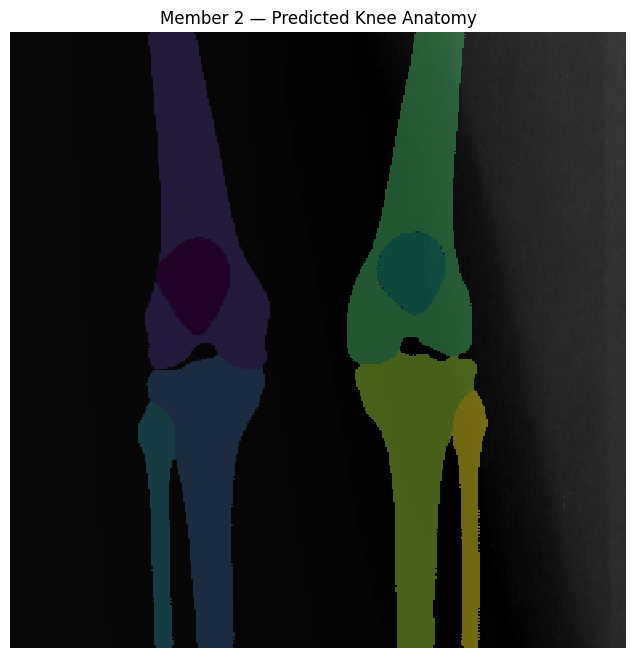

In [114]:
# CELL 99 — Display predicted anatomy mask

plt.figure(figsize=(12, 8))

plt.imshow(
    result["original_image"],
    cmap="gray"
)

pred_mask = np.ma.masked_where(
    result["mask"] == 0,
    result["mask"]
)

plt.imshow(
    pred_mask,
    alpha=0.45,
    interpolation="nearest"
)

plt.title(
    "Member 2 — Predicted Knee Anatomy"
)

plt.axis("off")
plt.show()

In [115]:
# CELL 100 — Anatomy landmarks

def calculate_landmarks(mask):

    landmarks = {}

    for class_id, class_name in LABELS.items():

        if class_id == 0:
            continue

        ys, xs = np.where(mask == class_id)

        if len(xs) == 0:
            landmarks[class_name] = None
            continue

        landmarks[class_name] = {
            "centroid": (
                round(float(xs.mean()), 1),
                round(float(ys.mean()), 1)
            ),
            "bbox": {
                "x_min": int(xs.min()),
                "y_min": int(ys.min()),
                "x_max": int(xs.max()),
                "y_max": int(ys.max())
            },
            "pixels": int(len(xs))
        }

    return landmarks


landmarks = calculate_landmarks(
    result["mask"]
)

for name, data in landmarks.items():

    if data is None:
        print(f"{name}: not detected")
    else:
        print(
            f"{name}: "
            f"centroid={data['centroid']}, "
            f"pixels={data['pixels']:,}"
        )

R Patella: centroid=(114.9, 155.6), pixels=1,961
R Femur: centroid=(116.7, 112.1), pixels=7,979
R Tibia: centroid=(123.7, 275.7), pixels=6,493
R Fibula: centroid=(92.8, 298.9), pixels=2,064
L Patella: centroid=(250.1, 148.3), pixels=1,645
L Femur: centroid=(254.0, 111.8), pixels=8,156
L Tibia: centroid=(252.4, 272.5), pixels=6,689
L Fibula: centroid=(286.3, 295.8), pixels=2,023


In [116]:
# CELL 101 — Structured Member 2 result

member2_result = {
    "anatomy_classes": LABELS,
    "predicted_mask": result["mask"],
    "confidence": result["confidence"],
    "landmarks": landmarks
}

print("====================================")
print("MEMBER 2 — KNEE ANATOMY ASSESSMENT")
print("====================================")

print(
    "Mean segmentation confidence:",
    f"{result['confidence']:.3f}"
)

print(
    "Detected structures:",
    sum(
        x is not None
        for x in landmarks.values()
    ),
    "/",
    len(landmarks)
)

print("\nDetected anatomy:")

for name, data in landmarks.items():

    if data is not None:
        print(
            f"  ✓ {name}"
        )
    else:
        print(
            f"  ✗ {name}"
        )

MEMBER 2 — KNEE ANATOMY ASSESSMENT
Mean segmentation confidence: 0.750
Detected structures: 8 / 8

Detected anatomy:
  ✓ R Patella
  ✓ R Femur
  ✓ R Tibia
  ✓ R Fibula
  ✓ L Patella
  ✓ L Femur
  ✓ L Tibia
  ✓ L Fibula


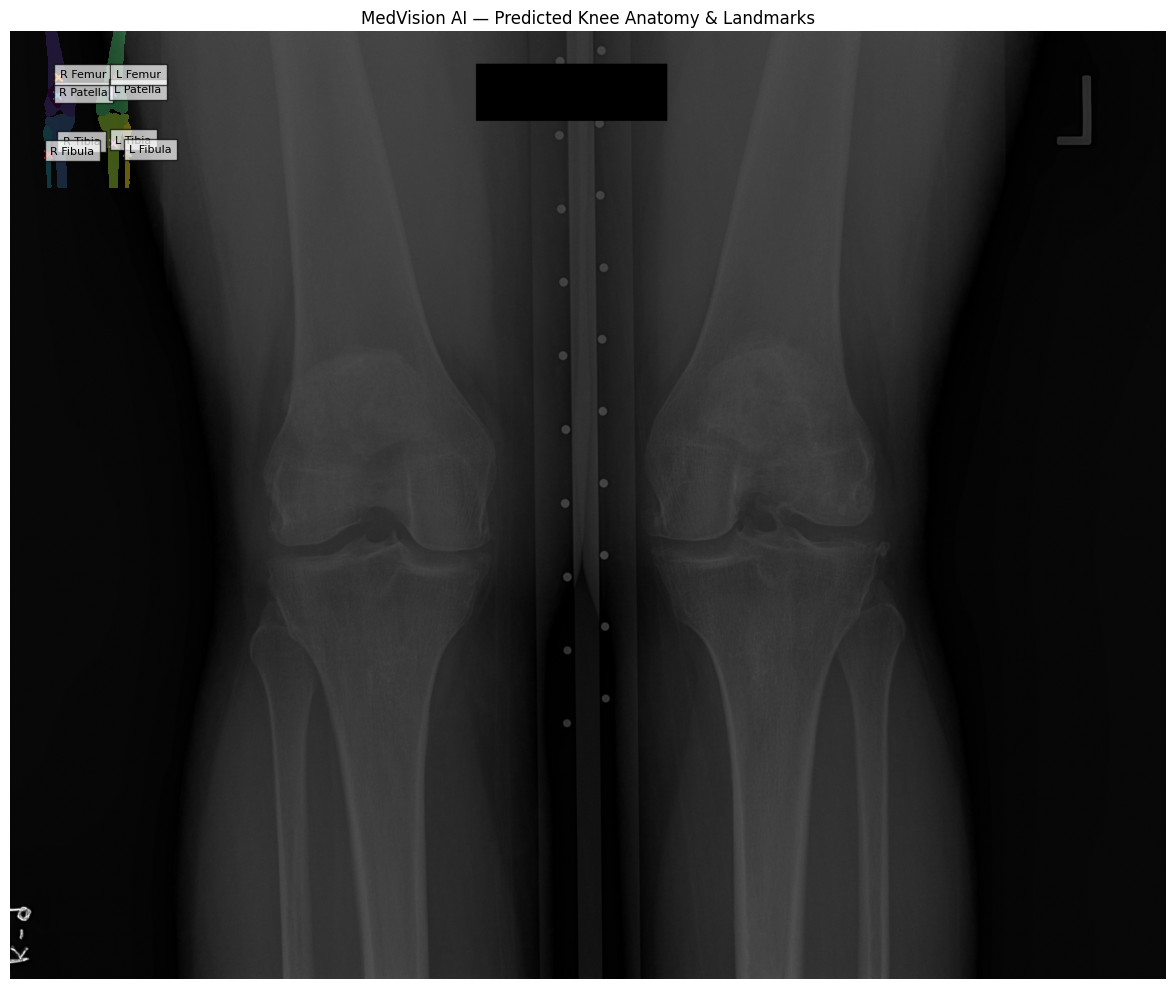

In [117]:
# CELL 102 — Labeled anatomy visualization

import matplotlib.pyplot as plt
import numpy as np

def visualize_anatomy(result, landmarks):

    image = result["original_image"]
    mask = result["mask"]

    plt.figure(figsize=(14, 10))

    plt.imshow(image, cmap="gray")

    # Overlay segmentation
    overlay = np.ma.masked_where(
        mask == 0,
        mask
    )

    plt.imshow(
        overlay,
        alpha=0.40,
        interpolation="nearest"
    )

    # Add centroid labels
    for class_id, class_name in LABELS.items():

        if class_id == 0:
            continue

        data = landmarks.get(class_name)

        if data is None:
            continue

        x, y = data["centroid"]

        plt.scatter(
            x,
            y,
            s=35,
            marker="x"
        )

        plt.text(
            x + 5,
            y,
            class_name,
            fontsize=8,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

    plt.title(
        "MedVision AI — Predicted Knee Anatomy & Landmarks"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_anatomy(
    result,
    landmarks
)

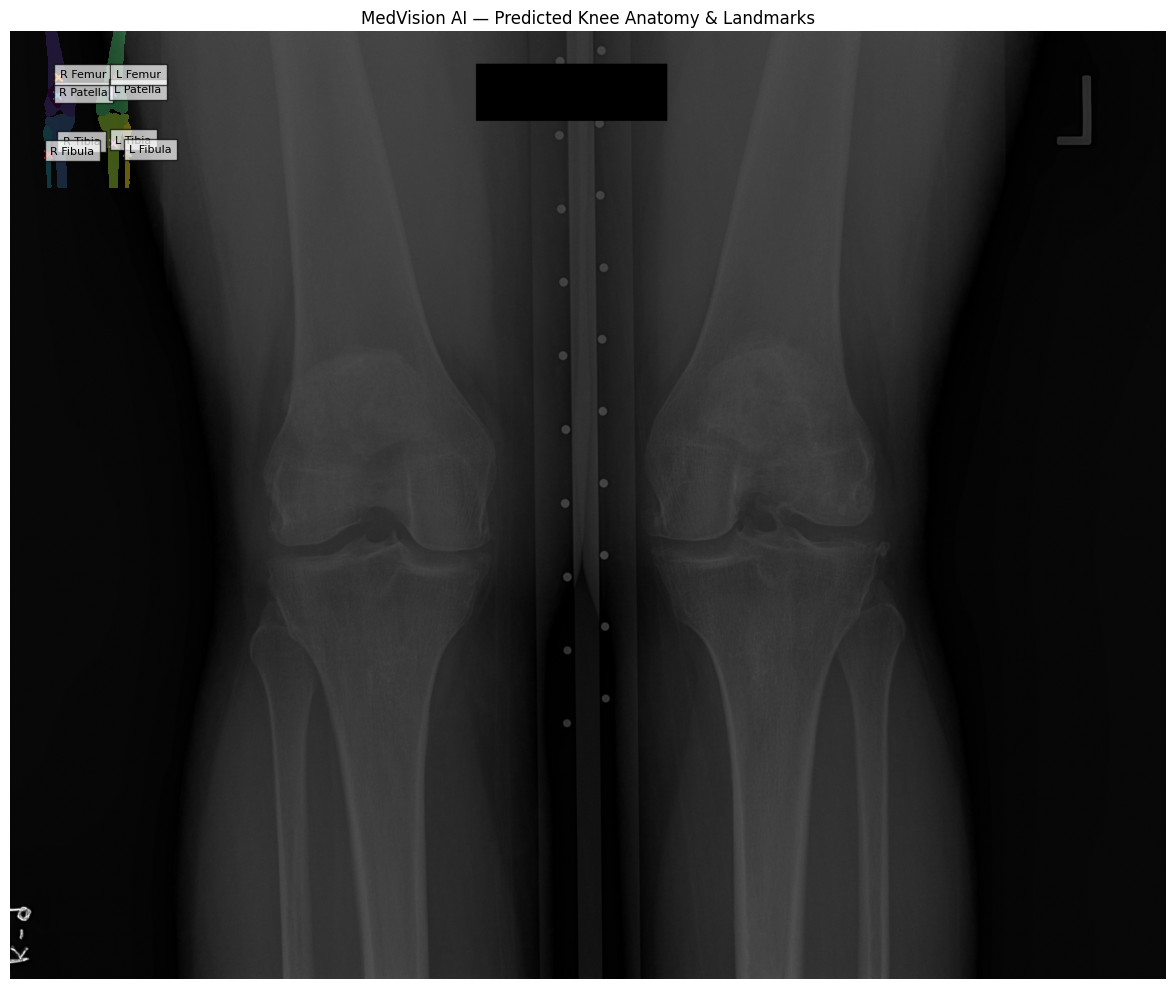

In [118]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_anatomy(result, landmarks):
    image = result["original_image"]
    mask = result["mask"]

    plt.figure(figsize=(14, 10))

    # Original X-ray
    plt.imshow(image, cmap="gray")

    # Segmentation overlay
    overlay = np.ma.masked_where(mask == 0, mask)
    plt.imshow(
        overlay,
        alpha=0.40,
        interpolation="nearest"
    )

    # Landmarks
    for class_id, class_name in LABELS.items():
        if class_id == 0:
            continue

        data = landmarks.get(class_name)

        if data is None:
            continue

        x, y = data["centroid"]

        plt.scatter(
            x, y,
            s=35,
            marker="x"
        )

        plt.text(
            x + 5,
            y,
            class_name,
            fontsize=8,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

    plt.title(
        "MedVision AI — Predicted Knee Anatomy & Landmarks"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_anatomy(result, landmarks)

In [119]:
import os

model_path = "/content/MedVision_AI_Member1_2_ActualData/models/anatomy_resnet18_unet_9class.pt"

print("Checkpoint:", model_path)
print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Size: {size_mb:.2f} MB")

Checkpoint: /content/MedVision_AI_Member1_2_ActualData/models/anatomy_resnet18_unet_9class.pt
Exists: True
Size: 54.80 MB


In [120]:
# ============================================================
# MedVision AI — Member 2
# Knee Anatomy Segmentation & Landmark Detection
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms.functional as TF
import pydicom
from PIL import Image


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_CLASSES = 9
IMAGE_SIZE = 384

LABELS = {
    0: "Background",
    1: "R Patella",
    2: "R Femur",
    3: "R Tibia",
    4: "R Fibula",
    5: "L Patella",
    6: "L Femur",
    7: "L Tibia",
    8: "L Fibula"
}


# ------------------------------------------------------------
# ResNet18 U-Net
# ------------------------------------------------------------

class ResNet18UNet(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):

        super().__init__()

        backbone = models.resnet18(
            weights=None
        )

        self.enc1 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.pool1 = backbone.maxpool

        self.enc2 = backbone.layer1
        self.enc3 = backbone.layer2
        self.enc4 = backbone.layer3
        self.enc5 = backbone.layer4

        self.up4 = nn.ConvTranspose2d(
            512, 256, 2, stride=2
        )

        self.dec4 = self.conv_block(
            512, 256
        )

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.dec3 = self.conv_block(
            256, 128
        )

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.dec2 = self.conv_block(
            128, 64
        )

        self.up1 = nn.ConvTranspose2d(
            64, 64, 2, stride=2
        )

        self.dec1 = self.conv_block(
            128, 64
        )

        self.up0 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )

        self.final = nn.Sequential(
            nn.Conv2d(
                32, 32, 3, padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                num_classes,
                1
            )
        )


    @staticmethod
    def conv_block(
        in_channels,
        out_channels
    ):

        return nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )


    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = self.up4(e5)
        d4 = torch.cat(
            [d4, e4],
            dim=1
        )
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat(
            [d3, e3],
            dim=1
        )
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat(
            [d2, e2],
            dim=1
        )
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat(
            [d1, e1],
            dim=1
        )
        d1 = self.dec1(d1)

        out = self.up0(d1)

        out = self.final(out)

        return out


# ------------------------------------------------------------
# Anatomy Inference
# ------------------------------------------------------------

class AnatomyInference:

    def __init__(
        self,
        checkpoint_path
    ):

        self.device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        if not os.path.exists(
            checkpoint_path
        ):
            raise FileNotFoundError(
                f"Checkpoint not found: {checkpoint_path}"
            )

        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.device,
            weights_only=False
        )

        self.model = ResNet18UNet(
            num_classes=NUM_CLASSES
        )

        self.model.load_state_dict(
            checkpoint["model_state"]
        )

        self.model.to(
            self.device
        )

        self.model.eval()

        self.image_size = checkpoint.get(
            "image_size",
            IMAGE_SIZE
        )


    # --------------------------------------------------------
    # Image preprocessing
    # --------------------------------------------------------

    def preprocess_image(
        self,
        image
    ):

        # PIL image
        if isinstance(
            image,
            Image.Image
        ):

            image = image.convert(
                "L"
            )

            original = np.array(
                image
            )

        # NumPy image
        elif isinstance(
            image,
            np.ndarray
        ):

            original = image.copy()

            if original.ndim == 3:

                if original.shape[2] == 3:

                    image = Image.fromarray(
                        original.astype(
                            np.uint8
                        )
                    ).convert("L")

                else:

                    original = np.squeeze(
                        original
                    )

                    image = Image.fromarray(
                        original.astype(
                            np.uint8
                        )
                    )

            else:

                image = Image.fromarray(
                    original.astype(
                        np.uint8
                    )
                )

        else:

            raise TypeError(
                "Input must be a PIL image or NumPy array."
            )


        original = np.asarray(
            image
        ).astype(
            np.float32
        )


        # Normalize
        original -= original.min()

        max_value = original.max()

        if max_value > 0:

            original /= max_value

        original_uint8 = (
            original * 255
        ).astype(
            np.uint8
        )


        # RGB for ResNet
        rgb_image = Image.fromarray(
            original_uint8
        ).convert(
            "RGB"
        )


        resized = rgb_image.resize(
            (
                self.image_size,
                self.image_size
            ),
            Image.Resampling.BILINEAR
        )


        tensor = TF.to_tensor(
            resized
        )

        tensor = TF.normalize(
            tensor,
            mean=[
                0.485,
                0.456,
                0.406
            ],
            std=[
                0.229,
                0.224,
                0.225
            ]
        )


        tensor = tensor.unsqueeze(
            0
        ).to(
            self.device
        )


        return (
            original_uint8,
            tensor
        )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    @torch.no_grad()
    def predict(
        self,
        image
    ):

        original_image, tensor = (
            self.preprocess_image(
                image
            )
        )


        logits = self.model(
            tensor
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )


        confidence_map, mask = (
            probabilities.max(
                dim=1
            )
        )


        mask = mask[
            0
        ].cpu().numpy()


        confidence_map = (
            confidence_map[
                0
            ].cpu().numpy()
        )


        mean_confidence = float(
            confidence_map.mean()
        )


        # Detect structures
        detected_structures = []

        for class_id in range(
            1,
            NUM_CLASSES
        ):

            if np.any(
                mask == class_id
            ):

                detected_structures.append(
                    LABELS[class_id]
                )


        # Calculate landmarks
        landmarks = (
            self.calculate_landmarks(
                mask
            )
        )


        # Resize mask back to original image
        original_h, original_w = (
            original_image.shape[:2]
        )

        mask_image = Image.fromarray(
            mask.astype(
                np.uint8
            )
        )

        mask_original = mask_image.resize(
            (
                original_w,
                original_h
            ),
            Image.Resampling.NEAREST
        )

        mask_original = np.array(
            mask_original
        )


        return {

            "original_image":
                original_image,

            "mask":
                mask_original,

            "confidence_map":
                confidence_map,

            "confidence":
                mean_confidence,

            "detected_structures":
                detected_structures,

            "landmarks":
                self.calculate_landmarks(
                    mask_original
                )
        }


    # --------------------------------------------------------
    # Landmark calculation
    # --------------------------------------------------------

    @staticmethod
    def calculate_landmarks(
        mask
    ):

        landmarks = {}

        for class_id, class_name in LABELS.items():

            if class_id == 0:
                continue

            ys, xs = np.where(
                mask == class_id
            )

            if len(xs) == 0:

                landmarks[
                    class_name
                ] = None

            else:

                landmarks[
                    class_name
                ] = {

                    "centroid": (
                        round(
                            float(
                                xs.mean()
                            ),
                            1
                        ),
                        round(
                            float(
                                ys.mean()
                            ),
                            1
                        )
                    ),

                    "bbox": {

                        "x_min":
                            int(xs.min()),

                        "y_min":
                            int(ys.min()),

                        "x_max":
                            int(xs.max()),

                        "y_max":
                            int(ys.max())
                    },

                    "pixels":
                        int(len(xs))
                }

        return landmarks

In [122]:
from pathlib import Path

module_path = Path(
    "/content/MedVision_AI_Member1_2_ActualData/member2_anatomy.py"
)

module_code = r'''
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms.functional as TF
from PIL import Image


NUM_CLASSES = 9
IMAGE_SIZE = 384

LABELS = {
    0: "Background",
    1: "R Patella",
    2: "R Femur",
    3: "R Tibia",
    4: "R Fibula",
    5: "L Patella",
    6: "L Femur",
    7: "L Tibia",
    8: "L Fibula"
}


class ResNet18UNet(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):

        super().__init__()

        backbone = models.resnet18(weights=None)

        self.enc1 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.pool1 = backbone.maxpool

        self.enc2 = backbone.layer1
        self.enc3 = backbone.layer2
        self.enc4 = backbone.layer3
        self.enc5 = backbone.layer4

        self.up4 = nn.ConvTranspose2d(
            512, 256, 2, stride=2
        )

        self.dec4 = self.conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.dec3 = self.conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.dec2 = self.conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 64, 2, stride=2
        )

        self.dec1 = self.conv_block(128, 64)

        self.up0 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )

        self.final = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, 1)
        )


    @staticmethod
    def conv_block(in_channels, out_channels):

        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = self.up4(e5)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.up0(d1)

        return self.final(out)


class AnatomyInference:

    def __init__(self, checkpoint_path):

        self.device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(
                f"Checkpoint not found: {checkpoint_path}"
            )

        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.device,
            weights_only=False
        )

        self.model = ResNet18UNet(
            num_classes=NUM_CLASSES
        )

        self.model.load_state_dict(
            checkpoint["model_state"]
        )

        self.model.to(self.device)
        self.model.eval()

        self.image_size = checkpoint.get(
            "image_size",
            IMAGE_SIZE
        )


    def preprocess_image(self, image):

        if isinstance(image, Image.Image):

            image = image.convert("L")
            original = np.array(image)

        elif isinstance(image, np.ndarray):

            original = image.copy()

            if original.ndim == 3:

                if original.shape[2] == 3:

                    image = Image.fromarray(
                        original.astype(np.uint8)
                    ).convert("L")

                else:

                    original = np.squeeze(original)

                    image = Image.fromarray(
                        original.astype(np.uint8)
                    )

            else:

                image = Image.fromarray(
                    original.astype(np.uint8)
                )

        else:

            raise TypeError(
                "Input must be a PIL image or NumPy array."
            )


        original = np.asarray(
            image
        ).astype(np.float32)

        original -= original.min()

        max_value = original.max()

        if max_value > 0:
            original /= max_value

        original_uint8 = (
            original * 255
        ).astype(np.uint8)


        rgb_image = Image.fromarray(
            original_uint8
        ).convert("RGB")


        resized = rgb_image.resize(
            (
                self.image_size,
                self.image_size
            ),
            Image.Resampling.BILINEAR
        )


        tensor = TF.to_tensor(resized)

        tensor = TF.normalize(
            tensor,
            mean=[
                0.485,
                0.456,
                0.406
            ],
            std=[
                0.229,
                0.224,
                0.225
            ]
        )

        tensor = tensor.unsqueeze(0).to(
            self.device
        )

        return original_uint8, tensor


    @torch.no_grad()
    def predict(self, image):

        original_image, tensor = (
            self.preprocess_image(image)
        )

        logits = self.model(tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence_map, mask = (
            probabilities.max(dim=1)
        )

        mask = (
            mask[0]
            .cpu()
            .numpy()
        )

        confidence_map = (
            confidence_map[0]
            .cpu()
            .numpy()
        )

        mean_confidence = float(
            confidence_map.mean()
        )


        detected_structures = []

        for class_id in range(
            1,
            NUM_CLASSES
        ):

            if np.any(mask == class_id):

                detected_structures.append(
                    LABELS[class_id]
                )


        original_h, original_w = (
            original_image.shape[:2]
        )

        mask_image = Image.fromarray(
            mask.astype(np.uint8)
        )

        mask_original = mask_image.resize(
            (
                original_w,
                original_h
            ),
            Image.Resampling.NEAREST
        )

        mask_original = np.array(
            mask_original
        )


        landmarks = self.calculate_landmarks(
            mask_original
        )


        return {
            "original_image": original_image,
            "mask": mask_original,
            "confidence_map": confidence_map,
            "confidence": mean_confidence,
            "detected_structures": detected_structures,
            "landmarks": landmarks
        }


    @staticmethod
    def calculate_landmarks(mask):

        landmarks = {}

        for class_id, class_name in LABELS.items():

            if class_id == 0:
                continue

            ys, xs = np.where(
                mask == class_id
            )

            if len(xs) == 0:

                landmarks[class_name] = None

            else:

                landmarks[class_name] = {
                    "centroid": (
                        round(
                            float(xs.mean()),
                            1
                        ),
                        round(
                            float(ys.mean()),
                            1
                        )
                    ),

                    "bbox": {
                        "x_min": int(xs.min()),
                        "y_min": int(ys.min()),
                        "x_max": int(xs.max()),
                        "y_max": int(ys.max())
                    },

                    "pixels": int(len(xs))
                }

        return landmarks
'''

module_path.write_text(
    module_code,
    encoding="utf-8"
)

print("====================================")
print("MEMBER 2 MODULE CREATED")
print("====================================")
print("Path:", module_path)
print("Exists:", module_path.exists())
print("Size:", round(module_path.stat().st_size / 1024, 2), "KB")

MEMBER 2 MODULE CREATED
Path: /content/MedVision_AI_Member1_2_ActualData/member2_anatomy.py
Exists: True
Size: 8.07 KB


In [123]:
import sys
import os

PROJECT_DIR = "/content/MedVision_AI_Member1_2_ActualData"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from member2_anatomy import AnatomyInference

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "anatomy_resnet18_unet_9class.pt"
)

anatomy_model = AnatomyInference(
    MODEL_PATH
)

print("====================================")
print("MEMBER 2 MODULE LOADED")
print("====================================")
print("Device:", anatomy_model.device)
print("Image size:", anatomy_model.image_size)
print("Classes:", 9)
print("✅ SUCCESS")

MEMBER 2 MODULE LOADED
Device: cuda
Image size: 384
Classes: 9
✅ SUCCESS


In [124]:
import os

oa_model_path = (
    "/content/MedVision_AI_Member1_2_ActualData/"
    "models/oa_kl_efficientnet_b0.pt"
)

print("====================================")
print("MEMBER 1 CHECKPOINT")
print("====================================")
print("Path:", oa_model_path)
print("Exists:", os.path.exists(oa_model_path))

if os.path.exists(oa_model_path):
    size_mb = os.path.getsize(oa_model_path) / (1024 * 1024)
    print(f"Size: {size_mb:.2f} MB")
    print("✅ Member 1 checkpoint ready")
else:
    print("❌ Checkpoint not found")

MEMBER 1 CHECKPOINT
Path: /content/MedVision_AI_Member1_2_ActualData/models/oa_kl_efficientnet_b0.pt
Exists: True
Size: 15.61 MB
✅ Member 1 checkpoint ready


In [125]:
from pathlib import Path

PROJECT_DIR = Path("/content/MedVision_AI_Member1_2_ActualData")
APP_PATH = PROJECT_DIR / "app.py"

app_code = r'''
import os
import io
import numpy as np
import streamlit as st
import torch
import matplotlib.pyplot as plt

from PIL import Image

# Optional DICOM support
try:
    import pydicom
    DICOM_AVAILABLE = True
except ImportError:
    DICOM_AVAILABLE = False

from member1_oa import OAInference
from member2_anatomy import AnatomyInference, LABELS


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="MedVision AI",
    page_icon="🩻",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

OA_MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "oa_kl_efficientnet_b0.pt"
)

ANATOMY_MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "anatomy_resnet18_unet_9class.pt"
)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

.main-title {
    font-size: 42px;
    font-weight: 800;
    margin-bottom: 0;
}

.subtitle {
    font-size: 18px;
    opacity: 0.75;
    margin-top: 4px;
    margin-bottom: 25px;
}

.result-card {
    padding: 18px;
    border-radius: 12px;
    border: 1px solid rgba(128,128,128,0.25);
    margin-bottom: 12px;
}

.metric-title {
    font-size: 14px;
    opacity: 0.7;
}

.metric-value {
    font-size: 26px;
    font-weight: 700;
}

.disclaimer {
    padding: 15px;
    border-radius: 10px;
    border: 1px solid rgba(255,180,0,0.4);
    margin-top: 20px;
    font-size: 14px;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# HEADER
# ============================================================

st.markdown(
    '<div class="main-title">🩻 MedVision AI</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'Explainable Multi-Task AI System for Knee X-Ray Assessment'
    '</div>',
    unsafe_allow_html=True
)

st.write(
    "Upload a knee X-ray to obtain AI-assisted "
    "osteoarthritis grading, anatomical segmentation, "
    "landmarks and an explainable assessment."
)


# ============================================================
# MODEL LOADING
# ============================================================

@st.cache_resource
def load_models():

    oa_model = OAInference(
        OA_MODEL_PATH
    )

    anatomy_model = AnatomyInference(
        ANATOMY_MODEL_PATH
    )

    return oa_model, anatomy_model


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.header("MedVision AI")

    st.write(
        "### AI Modules"
    )

    st.write("✓ Osteoarthritis / KL grading")
    st.write("✓ Knee anatomy segmentation")
    st.write("✓ Anatomical landmarks")
    st.write("✓ Model uncertainty")
    st.write("✓ Grad-CAM explainability")
    st.write("✓ Groq-generated explanation")

    st.divider()

    st.write("### Model Information")

    st.write(
        "**Member 1:** EfficientNet-B0"
    )

    st.write(
        "**Member 2:** ResNet18 U-Net"
    )

    st.write(
        "**Anatomy classes:** 9"
    )

    st.divider()

    st.caption(
        "Hackathon research prototype — "
        "not a clinical diagnostic device."
    )


# ============================================================
# UPLOAD
# ============================================================

uploaded_file = st.file_uploader(
    "Upload Knee X-Ray",
    type=[
        "png",
        "jpg",
        "jpeg",
        "dcm"
    ],
    help="Upload a knee X-ray image."
)


# ============================================================
# IMAGE CONVERSION
# ============================================================

def load_uploaded_image(uploaded_file):

    filename = uploaded_file.name.lower()

    if filename.endswith(".dcm"):

        if not DICOM_AVAILABLE:

            raise RuntimeError(
                "pydicom is required for DICOM files."
            )

        data = uploaded_file.read()

        ds = pydicom.dcmread(
            io.BytesIO(data)
        )

        image = ds.pixel_array.astype(
            np.float32
        )

        if getattr(
            ds,
            "PhotometricInterpretation",
            ""
        ) == "MONOCHROME1":

            image = (
                image.max() - image
            )

        image -= image.min()

        if image.max() > 0:
            image /= image.max()

        image = (
            image * 255
        ).astype(
            np.uint8
        )

        return Image.fromarray(
            image
        ).convert("RGB")

    return Image.open(
        uploaded_file
    ).convert("RGB")


# ============================================================
# ANATOMY OVERLAY
# ============================================================

def create_anatomy_overlay(
    image,
    mask
):

    image_array = np.asarray(
        image
    ).astype(
        np.float32
    )

    if image_array.ndim == 3:
        image_array = image_array.mean(
            axis=2
        )

    image_array -= image_array.min()

    if image_array.max() > 0:
        image_array /= image_array.max()

    image_array = (
        image_array * 255
    ).astype(
        np.uint8
    )

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    ax.imshow(
        image_array,
        cmap="gray"
    )

    overlay = np.ma.masked_where(
        mask == 0,
        mask
    )

    ax.imshow(
        overlay,
        alpha=0.42,
        interpolation="nearest"
    )

    for class_id, class_name in LABELS.items():

        if class_id == 0:
            continue

        ys, xs = np.where(
            mask == class_id
        )

        if len(xs) == 0:
            continue

        x = xs.mean()
        y = ys.mean()

        ax.scatter(
            x,
            y,
            s=35,
            marker="x"
        )

        ax.text(
            x + 5,
            y,
            class_name,
            fontsize=8,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

    ax.set_title(
        "Predicted Anatomy & Landmarks"
    )

    ax.axis("off")

    fig.tight_layout()

    return fig


# ============================================================
# GRAD-CAM
# ============================================================

def create_gradcam_overlay(
    image,
    cam
):

    image_array = np.asarray(
        image
    )

    fig, ax = plt.subplots(
        figsize=(8, 7)
    )

    ax.imshow(
        image_array,
        cmap="gray"
    )

    ax.imshow(
        cam,
        alpha=0.45,
        cmap="jet"
    )

    ax.set_title(
        "Grad-CAM — OA Model Attention"
    )

    ax.axis("off")

    fig.tight_layout()

    return fig


# ============================================================
# GROQ
# ============================================================

def generate_groq_report(
    oa_result,
    anatomy_result
):

    api_key = os.getenv(
        "GROQ_API_KEY"
    )

    if not api_key:
        return None, (
            "GROQ_API_KEY is not configured. "
            "The model results are still available."
        )

    try:

        from groq import Groq

        client = Groq(
            api_key=api_key
        )

        model_name = os.getenv(
            "GROQ_MODEL",
            "llama-3.1-8b-instant"
        )

        structures = (
            anatomy_result[
                "detected_structures"
            ]
        )

        prompt = f"""
You are an AI assistant supporting a knee X-ray
research prototype.

Summarize ONLY the model-generated findings below.
Do not invent symptoms, clinical history, measurements,
or diagnoses.

OA model:
- KL grade: {oa_result["kl_grade"]}
- KL label: {oa_result["kl_label"]}
- OA pattern suspected: {oa_result["oa_suspected"]}
- Model confidence: {oa_result["confidence"]:.3f}
- Model uncertainty: {oa_result["uncertainty"]:.3f}

Anatomy model:
- Detected structures: {structures}
- Segmentation confidence: {anatomy_result["confidence"]:.3f}

Provide:
1. Key findings
2. What the KL grade represents
3. Anatomy findings
4. A short plain-language explanation
5. A clear statement that this is an AI research prototype
   and not a clinical diagnosis.

Keep the response concise.
"""

        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0.2,
            max_tokens=500
        )

        return (
            response.choices[0].message.content,
            None
        )

    except Exception as e:

        return None, (
            f"Groq explanation unavailable: {str(e)}"
        )


# ============================================================
# MAIN ANALYSIS
# ============================================================

if uploaded_file is not None:

    try:

        image = load_uploaded_image(
            uploaded_file
        )

        st.image(
            image,
            caption="Uploaded Knee X-Ray",
            width="stretch"
        )

        if st.button(
            "🔍 Analyze X-Ray",
            type="primary",
            use_container_width=True
        ):

            with st.spinner(
                "Running MedVision AI..."
            ):

                oa_model, anatomy_model = (
                    load_models()
                )

                # -------------------------------
                # Member 1
                # -------------------------------

                oa_result = oa_model.predict(
                    image,
                    with_gradcam=True
                )

                # -------------------------------
                # Member 2
                # -------------------------------

                anatomy_result = (
                    anatomy_model.predict(
                        image
                    )
                )


            st.success(
                "Analysis completed successfully."
            )


            # =================================================
            # OA RESULTS
            # =================================================

            st.header(
                "1. Osteoarthritis Assessment"
            )

            c1, c2, c3, c4 = st.columns(4)

            with c1:
                st.metric(
                    "KL Grade",
                    oa_result["kl_label"]
                )

            with c2:

                status = (
                    "Pattern suspected"
                    if oa_result["oa_suspected"]
                    else "Not suspected"
                )

                st.metric(
                    "OA Pattern",
                    status
                )

            with c3:

                st.metric(
                    "Model Confidence",
                    f'{oa_result["confidence"] * 100:.1f}%'
                )

            with c4:

                st.metric(
                    "Uncertainty",
                    f'{oa_result["uncertainty"] * 100:.1f}%'
                )


            st.subheader(
                "KL Grade Probabilities"
            )

            probability_data = (
                oa_result["probabilities"]
            )

            st.bar_chart(
                probability_data
            )


            # =================================================
            # ANATOMY
            # =================================================

            st.header(
                "2. Knee Anatomy Segmentation"
            )

            c1, c2 = st.columns(
                [2, 1]
            )

            with c1:

                fig = create_anatomy_overlay(
                    anatomy_result[
                        "original_image"
                    ],
                    anatomy_result[
                        "mask"
                    ]
                )

                st.pyplot(
                    fig,
                    width="stretch"
                )

                plt.close(fig)


            with c2:

                st.metric(
                    "Segmentation Confidence",
                    f'{anatomy_result["confidence"] * 100:.1f}%'
                )

                st.metric(
                    "Structures Detected",
                    f'{len(anatomy_result["detected_structures"])}/8'
                )

                st.subheader(
                    "Detected Structures"
                )

                for structure in (
                    anatomy_result[
                        "detected_structures"
                    ]
                ):

                    st.write(
                        f"✓ {structure}"
                    )


            # =================================================
            # LANDMARKS
            # =================================================

            st.header(
                "3. Anatomical Landmarks"
            )

            landmark_rows = []

            for name, data in (
                anatomy_result[
                    "landmarks"
                ].items()
            ):

                if data is None:
                    continue

                x, y = data[
                    "centroid"
                ]

                landmark_rows.append(
                    {
                        "Structure": name,
                        "Centroid X": x,
                        "Centroid Y": y,
                        "Pixels": data[
                            "pixels"
                        ]
                    }
                )

            if landmark_rows:

                st.dataframe(
                    landmark_rows,
                    use_container_width=True,
                    hide_index=True
                )


            # =================================================
            # EXPLAINABILITY
            # =================================================

            st.header(
                "4. Explainability"
            )

            if (
                oa_result.get(
                    "gradcam"
                ) is not None
            ):

                fig = create_gradcam_overlay(
                    image,
                    oa_result["gradcam"]
                )

                st.pyplot(
                    fig,
                    width="stretch"
                )

                plt.close(fig)

                st.caption(
                    "Grad-CAM highlights regions that "
                    "influenced the OA classification model. "
                    "It is an explanatory visualization, "
                    "not a diagnostic boundary."
                )


            # =================================================
            # GROQ REPORT
            # =================================================

            st.header(
                "5. AI-Generated Explanation"
            )

            with st.spinner(
                "Generating explanation..."
            ):

                report, error = (
                    generate_groq_report(
                        oa_result,
                        anatomy_result
                    )
                )

            if report:

                st.markdown(
                    report
                )

            else:

                st.info(
                    error
                )


            # =================================================
            # DISCLAIMER
            # =================================================

            st.markdown(
                """
                <div class="disclaimer">
                <b>Research Prototype Disclaimer:</b><br>
                MedVision AI is a hackathon/research prototype.
                Its outputs are generated by machine-learning
                models and are not clinically validated.
                KL grading, segmentation confidence,
                uncertainty and landmarks should not be used
                as a substitute for assessment by a qualified
                healthcare professional.
                </div>
                """,
                unsafe_allow_html=True
            )


    except Exception as e:

        st.error(
            f"Unable to analyze the uploaded image: {str(e)}"
        )

else:

    st.info(
        "👆 Upload a knee X-ray to begin the analysis."
    )
'''

APP_PATH.write_text(
    app_code,
    encoding="utf-8"
)

print("====================================")
print("FINAL APP CREATED")
print("====================================")
print("Path:", APP_PATH)
print("Exists:", APP_PATH.exists())
print("Size:", round(APP_PATH.stat().st_size / 1024, 2), "KB")

FINAL APP CREATED
Path: /content/MedVision_AI_Member1_2_ActualData/app.py
Exists: True
Size: 16.45 KB


In [126]:
import os

files_to_check = [
    "/content/MedVision_AI_Member1_2_ActualData/app.py",
    "/content/MedVision_AI_Member1_2_ActualData/member1_oa.py",
    "/content/MedVision_AI_Member1_2_ActualData/member2_anatomy.py",
    "/content/MedVision_AI_Member1_2_ActualData/models/oa_kl_efficientnet_b0.pt",
    "/content/MedVision_AI_Member1_2_ActualData/models/anatomy_resnet18_unet_9class.pt",
]

for path in files_to_check:
    exists = os.path.exists(path)
    size = (
        os.path.getsize(path) / (1024 * 1024)
        if exists else 0
    )

    print(
        f"{'✅' if exists else '❌'} "
        f"{os.path.basename(path)} "
        f"({size:.2f} MB)"
    )

✅ app.py (0.02 MB)
✅ member1_oa.py (0.01 MB)
✅ member2_anatomy.py (0.01 MB)
✅ oa_kl_efficientnet_b0.pt (15.61 MB)
✅ anatomy_resnet18_unet_9class.pt (54.80 MB)


In [127]:
!pip -q install streamlit groq pydicom nibabel

In [128]:
import streamlit
import groq
import pydicom

print("Streamlit:", streamlit.__version__)
print("Groq: imported successfully")
print("pydicom: imported successfully")
print("✅ Dependencies ready")

Streamlit: 1.63.0
Groq: imported successfully
pydicom: imported successfully
✅ Dependencies ready


In [131]:
from PIL import Image

# Convert DICOM X-ray NumPy array → PIL RGB image
xray_normalized = xray.copy().astype(np.float32)

xray_normalized -= xray_normalized.min()

if xray_normalized.max() > 0:
    xray_normalized /= xray_normalized.max()

xray_uint8 = (xray_normalized * 255).astype(np.uint8)

xray_pil = Image.fromarray(xray_uint8).convert("RGB")

# ==============================
# MEMBER 1 — OA / KL GRADING
# ==============================
oa_result = oa_model.predict(
    xray_pil,
    with_gradcam=True
)

# ==============================
# MEMBER 2 — ANATOMY SEGMENTATION
# ==============================
anatomy_result = anatomy_model.predict(xray_pil)

# ==============================
# DISPLAY RESULTS
# ==============================
print("=" * 50)
print("MEDVISION AI — COMPLETE PIPELINE TEST")
print("=" * 50)

print("\n--- MEMBER 1: OA / KL GRADING ---")
print("KL Grade:", oa_result["kl_grade"])
print("KL Label:", oa_result["kl_label"])
print("OA Pattern Suspected:", oa_result["oa_suspected"])
print("Confidence:", round(oa_result["confidence"], 4))
print("Uncertainty:", round(oa_result["uncertainty"], 4))

print("\nKL Probabilities:")
for label, probability in oa_result["probabilities"].items():
    print(f"  {label}: {probability:.4f}")

print("\n--- MEMBER 2: KNEE ANATOMY ---")
print("Segmentation Confidence:",
      round(anatomy_result["confidence"], 4))

print(
    "Detected Structures:",
    len(anatomy_result["detected_structures"]),
    "/ 8"
)

for structure in anatomy_result["detected_structures"]:
    print("  ✓", structure)

print("\n--- FINAL CHECK ---")

if oa_result["gradcam"] is not None:
    print("✓ OA Grad-CAM generated")

if len(anatomy_result["detected_structures"]) > 0:
    print("✓ Anatomy segmentation generated")

if len(anatomy_result["landmarks"]) == 8:
    print("✓ Anatomical landmarks generated")

print("\n✓ COMPLETE PIPELINE TEST FINISHED")

MEDVISION AI — COMPLETE PIPELINE TEST

--- MEMBER 1: OA / KL GRADING ---
KL Grade: 1
KL Label: KL-1
OA Pattern Suspected: False
Confidence: 0.8804
Uncertainty: 0.3299

KL Probabilities:
  KL-0: 0.0323
  KL-1: 0.8804
  KL-2: 0.0348
  KL-3: 0.0280
  KL-4: 0.0245

--- MEMBER 2: KNEE ANATOMY ---
Segmentation Confidence: 0.7562
Detected Structures: 8 / 8
  ✓ R Patella
  ✓ R Femur
  ✓ R Tibia
  ✓ R Fibula
  ✓ L Patella
  ✓ L Femur
  ✓ L Tibia
  ✓ L Fibula

--- FINAL CHECK ---
✓ OA Grad-CAM generated
✓ Anatomy segmentation generated
✓ Anatomical landmarks generated

✓ COMPLETE PIPELINE TEST FINISHED


In [132]:
import os

PROJECT_DIR = "/content/MedVision_AI_Member1_2_ActualData"

files_to_check = [
    "app.py",
    "member1_oa.py",
    "member2_anatomy.py",
    "groq_assistant.py",
    "requirements.txt",
    "models/oa_kl_efficientnet_b0.pt",
    "models/anatomy_resnet18_unet_9class.pt"
]

print("MEDVISION AI — FINAL FILE CHECK")
print("=" * 50)

for f in files_to_check:
    path = os.path.join(PROJECT_DIR, f)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {f} — {size_mb:.2f} MB")
    else:
        print(f"❌ MISSING: {f}")

MEDVISION AI — FINAL FILE CHECK
✓ app.py — 0.02 MB
✓ member1_oa.py — 0.01 MB
✓ member2_anatomy.py — 0.01 MB
✓ groq_assistant.py — 0.00 MB
✓ requirements.txt — 0.00 MB
✓ models/oa_kl_efficientnet_b0.pt — 15.61 MB
✓ models/anatomy_resnet18_unet_9class.pt — 54.80 MB


In [133]:
%cd /content/MedVision_AI_Member1_2_ActualData

!python -m py_compile app.py

print("✓ app.py syntax check passed")

/content
✓ app.py syntax check passed


In [134]:
!pip install -q streamlit groq

In [135]:
import streamlit
import groq

print("Streamlit:", streamlit.__version__)
print("Groq: installed ✓")

Streamlit: 1.63.0
Groq: installed ✓


In [136]:
%cd /content/MedVision_AI_Member1_2_ActualData

!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

/content


In [137]:
!sleep 5
!cat /content/streamlit.log



2026-09-12 20:04:45.622 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.169.248.209:8501



In [138]:
!pkill -f streamlit || true

^C


In [139]:
%cd /content/MedVision_AI_Member1_2_ActualData

!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/streamlit.log 2>&1 &

/content


In [140]:
!sleep 8
!cat /content/streamlit.log



2026-09-12 20:08:46.099 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.169.248.209:8501



In [141]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [142]:
!nohup /content/cloudflared tunnel --url http://127.0.0.1:8501 > /content/cloudflare.log 2>&1 &

In [143]:
!sleep 8
!cat /content/cloudflare.log

2026-09-12T20:09:32Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-12T20:09:32Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-12T20:09:34Z INF +--------------------------------------------------------------------------------------------+
2026-09-12T20:09:34Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-12T20:09:34Z INF |  https://fairfield-coverage-personality-mid.trycloudfl